# PPR evidence notebook: ICS (AI engine, host, dashboard path)

**Team M001, Real-Time Edge Digital Twin for Bearing Fault Diagnosis and RUL Prediction in OH-2 Centrifugal Pumps.**
ICS owner of the models: Muhammad Jaddoua. Preliminary Prototype Review, 2026-10-05.

Every number below is **recomputed in a cell** from raw data, trained ONNX models, stored per-window predictions,
or a live program (`dotnet test`, the ASP.NET backend, the SignalR measurement client). The only numbers that are
not recomputed are the ones explicitly loaded from a stored report, and those cells say so.

**Executed at git commit:** the first code cell prints `git HEAD` at execution time; the saved outputs in this
copy (and in `PPR_ICS_Evidence.html`) were executed at that commit. **v2 disclosure:** v2 = second look at the XJTU-SY/IMS
test bearings; v2 choices were made on validation only; v1 results are kept in `AI-engine/reports/`.

### How to run
1. Kernel **`dt-aiengine`** (Python venv `Repo/Digital-Twin-Senior-Proj/AI-test/.venv`). The .NET 10 SDK on `PATH`.
2. Raw data: `AI-engine/data` is git-ignored. The helper looks in `$AIENGINE_DATA_DIR`, then this worktree, then the
   sibling `Repo/Digital-Twin-Senior-Proj/AI-engine/data` checkout.
3. **Kernel, then Restart & Run All.** It takes about 3 to 4 minutes; the measured run time is printed at the end.
   Batch version: `jupyter nbconvert --to notebook --execute --inplace --ExecutePreprocessor.kernel_name=dt-aiengine PPR_ICS_Evidence.ipynb`.
4. Backends started here bind to `127.0.0.1` on free ports and are stopped by PID at the end of their cell.
   They never touch a backend that is already running for the live dashboard demo.

### Provenance tags used on every number
| Tag | Meaning |
|---|---|
| `[MEASURED on XJTU-SY]` / `[MEASURED on IMS]` / `[MEASURED on MaFaulDa]` | real measurement of **that public dataset's bearings**, held-out test units only. Not the team rig. |
| `[MEASURED loopback, dev laptop; re-measure on the chosen server]` | timing measured live on this dev laptop, backend and client on one machine (no Wi-Fi hop, no COE node); to be repeated on the server the team chooses |
| `[SIMULATION]` | output of our own physics twin or synthetic twin-sim stream |
| `[SYNTHETIC]` | generated data (pipeline proof only) |
| `[CALCULATED]` | arithmetic on measured numbers and spec budgets |
| `[CITED: file]` | read from a stored report or team document, not recomputed here |

### Evidence ladder (course, PPR Expectations slide 4)
| Rank | Evidence | Rank | Evidence |
|---|---|---|---|
| 0 | words | 5 | video of the demo |
| 1 | sketches / diagrams | 6 | simulation / CAD + data |
| 2 | calculations and predictions | 7 | picture of the demo + data |
| 3 | simulation / CAD model | 8 | video of the demo + data |
| 4 | picture of the demo | **9** | **physical prototype or working simulation demo at the presentation** |

Run live in front of the reviewer, each cell is **Rank 9**. The saved copy with outputs (and `PPR_ICS_Evidence.html`)
is the **Rank 7 fallback** (picture of the demo + data).

**What "pretrained / fine-tuned" means here.** `pytorch-forecasting` ships no pretrained weights. "Pretrained" means
our own training of N-HiTS and TFT on public bearing data (XJTU-SY, IMS, MaFaulDa). "Fine-tuned" means adapting those
weights to a new machine's data: rehearsed on IMS, to be repeated on the team rig once it produces data.

In [1]:
import time, json, platform, os, sys
T_START = time.time()
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, HTML, update_display

import ppr_helpers as H
H.seed_everything(H.SEED)
H.style_matplotlib()
pd.set_option("display.width", 200, "display.max_colwidth", 120)

DATA = H.resolve_data_dir()
CKPT = H.resolve_checkpoint_dir()
DOTNET = H.dotnet_path()
print(f"git HEAD            : {H.git_head()}  (worktree {H.REPO.name}); outputs below were executed at this commit")
print(f"python / platform   : {sys.version.split()[0]} / {platform.platform()} / {os.cpu_count()} logical CPUs")
print(f"models              : {H.MODELS}")
print(f"data (raw + cache)  : {DATA}")
print(f"checkpoints (opt.)  : {CKPT}")
print(f"dotnet              : {DOTNET}")
print(f"seed                : {H.SEED}")
contract = json.loads((H.MODELS / 'model_contract.json').read_text())
print(f"model contract      : v{contract['contract_version']}, classes {contract['classes']['labels']}, decision {contract['classes'].get('decision', {}).get('type')}")

git HEAD            : 56a2d00 (+uncommitted changes)  (worktree DT-integration); outputs below were executed at this commit
python / platform   : 3.11.9 / Windows-10-10.0.26200-SP0 / 24 logical CPUs
models              : C:\Users\lenovo\Documents\KFUPM\Term261\ICS414\Repo\DT-integration\AI-engine\models
data (raw + cache)  : C:\Users\lenovo\Documents\KFUPM\Term261\ICS414\Repo\Digital-Twin-Senior-Proj\AI-engine\data
checkpoints (opt.)  : C:\Users\lenovo\Documents\KFUPM\Term261\ICS414\Repo\Digital-Twin-Senior-Proj\AI-engine\checkpoints\real_v2
dotnet              : C:\Program Files\dotnet\dotnet.EXE
seed                : 20261004
model contract      : v2, classes ['ball', 'cage', 'healthy', 'inner_race', 'outer_race'], decision rtf_onset_gate


## 1. Rubric scorecard (all 18 items)

Built **in code** from the results computed in sections 2 to 10. The table below is a live display: it starts as
"PENDING" and is overwritten by the last cell of the notebook, so it cannot drift from the evidence.
C4 is COE-assigned in the spec sheet; it is **counted for ICS: team decision 2026-10-05** (the system uses no cloud service; AI inference and dashboard run on the local host), so ICS counts C4 + C5 as constraints and S8 + S9 as specs. Other items owned by COE or ME are listed for completeness and are **not assessed here** (their owners present them).

PPR rubric `[CITED: .claude/FACTS.md, PPR Expectations]`: per department, Exemplary = more than 1 constraint and
1 specification met with satisfactory-or-better evidence. Team table, Exemplary = more than 50 % of the 18 items, i.e. at least 10.

Items with partial or supporting evidence that are **not** claimed as met are listed, with rank and provenance, in the section "Additional items with supporting evidence" after the verdict (section 11).


In [2]:
display(H.styled_scorecard(), display_id="scorecard")
display(Markdown("_ICS verdict: computed at the end of the notebook._"), display_id="verdict")

ID,Old ID,Item,Owner dept,ICS role,Status (this notebook),Evidence rank,Section,Evidence
C1,M1,OH-2 / Goulds 3196 STi+MTi target machine; housing envelope <=10 mm/s RMS,ME,none,"owned by ME, not assessed here",-,-,
C2,M2,Mains-powered node; SELV IEPE excitation 24 V / 4 mA over coax,COE,none,"owned by COE, not assessed here",-,-,
C3,M3,"Node BOM <=4,000 SAR; sell price <=8,000 SAR/node",ME (ICS approval: No),none,"owned by ME, not assessed here",-,-,
C4,C1,"All real-time DAQ + signal processing on local hardware, no cloud",COE,AI/host part,MET (AI/host part),9 live / 7 saved,2,"AI path ran with all Python sockets blocked (10.8 s, 80 raw snapshots); backend source has no outbound client. COE acquisition/DSP leg on the node: COE evidence"
C5,I1,Dashboard local-network only; no external/cloud exposure,ICS,owner,MET,9 live / 7 saved,3,"19/19 LanOnlyTests + UdpLanGuardTests pass live (HTTP: 4 public IPs -> 403, 5 private/loopback pass; UDP 5005: public senders dropped and counted, private accepted); guard in pipeline; live loopback 200. Kestrel binds 0.0.0.0 by default; -Bind restricts it to one interface. Firewall rules per backend README (not shown here)"
C6,-,UV-stabilised weather-resistant polymer enclosure,ME,none,"owned by ME, not assessed here",-,-,
S1,M4,"2x biaxial IEPE accelerometers, 4 ch (off-the-shelf)",ME,none,"owned by ME, not assessed here",-,-,
S2,M5,FE twin identifies bearing stiffness K with <=10% error,ME,twin code support,"owned by ME, not assessed here",-,9,
S3,M6,"Enclosure IP54, continuous operation",ME,none,"owned by ME, not assessed here",-,-,
S4,C2,"Sample rate >=25 kS/s/ch, 4 ch",COE,none,"owned by COE, not assessed here",-,-,


**ICS rubric verdict (computed).** Constraints met with ICS evidence: **C5, C4**
(2; C4 is counted for ICS: team decision 2026-10-05 (the system uses no cloud service; AI inference and dashboard run on the local host). C4 is COE-assigned in the spec sheet; the ICS evidence covers the AI/host part, the node acquisition/DSP part is COE evidence).
Specifications met: **S8, S9** (2).
Department Exemplary (more than 1 constraint and at least 1 spec): **YES**;
stricter reading (more than 1 spec as well): **YES**.

**Team table.** ICS evidence makes **4 of the 18 items MET** (C4, C5, S8, S9).
**IS1: PARTIAL: CONDITIONAL MET (host leg measured; COE leg at spec budget; Wi-Fi hop unmeasured, <= 128 ms allowed).** host leg (ONNX-active, warmed-up backend) p95 29.2 / max 38.7 ms; cold-start one-off 130.9 ms [MEASURED loopback, dev laptop; re-measure on the chosen server]; 333 ms COE leg [S5 spec budget (not yet measured)] + host max = 371.7 ms [CALCULATED]; Wi-Fi hop unmeasured, <= 128 ms allowed The team needs **at least 10**; the remaining
items must come from COE (C2, S4, S5, S6, and the node part of C4) and ME (C1, C6, S1, S2, S3), and IS1 counts once COE confirms its measured leg and the Wi-Fi hop is measured.
NOT MET and reported as such: **S7** (RUL), **IS3** (classification), **IS2** (physics-AI residual).

<DisplayHandle display_id=verdict>

## 2. C4: no cloud. The full AI path runs with the network disabled

C4 (COE-assigned): *all real-time data acquisition and signal processing shall execute on local hardware without
cloud computation.* The ICS share of C4 is the AI and host part, and C4 is **counted for ICS: team decision 2026-10-05** (the system uses no cloud service; AI inference and dashboard run on the local host); the node acquisition/DSP part stays COE evidence. Below, every Python network primitive
(`connect`, `connect_ex`, `sendto`, `create_connection`, `getaddrinfo`, `gethostbyname`) is replaced by a function
that raises. Inside that block: read raw XJTU-SY vibration CSVs, run the COE C3 to C7 DSP, encode 152-byte payloads,
and run the hybrid TFT + N-HiTS engine until it produces a classification, a health index and an RUL.

In [3]:
import urllib.request
files_b1, rpm_b1 = H.xjtu_files(DATA, "Bearing2_5")   # held-out TEST bearing (outer race, run to failure)
files_b2, rpm_b2 = H.xjtu_files(DATA, "Bearing3_4")   # held-out TEST bearing, healthy early life

with H.no_network():
    # 1) the guard really blocks: an HTTP request and a DNS lookup must both fail
    for what, fn in [("HTTP GET http://example.com", lambda: urllib.request.urlopen("http://example.com", timeout=3)),
                     ("DNS lookup pypi.org", lambda: H.socket.getaddrinfo("pypi.org", 443))]:
        try:
            fn()
            raise AssertionError(f"{what} succeeded: the no-network guard is NOT active")
        except H.NetworkBlocked as e:
            print(f"blocked as intended  : {what}")
    # 2) the full AI path, offline
    t0 = time.perf_counter()
    f1 = H.raw_bearing_features(files_b1, rpm_b1, n=40)
    f2 = H.raw_bearing_features(files_b2, rpm_b2, n=40)
    pls = H.build_payloads(f1, f2, rpm_b1)
    eng_off, outs_off, _ = H.run_engine(pls)
    dt = time.perf_counter() - t0

last = outs_off[-1]["bearings"][0]
assert last["status"] == "ok", f"engine did not reach a prediction offline: {last}"
print(f"\n[MEASURED on XJTU-SY] offline run: 40 raw snapshots x 2 bearings -> DSP -> 152-B payloads -> HybridEngine in {dt:.1f} s")
print(f"last window, bearing 1: class={last['fault_class']} conf={last['confidence']:.2f} HI={last['health_index']:.3f} "
      f"stage={last['health_stage']} RUL={last['rul_hours']:.2f} h")
print("first window, bearing 1:", outs_off[0]["bearings"][0])

# Host side: the backend source has no outbound HTTP client and no external URL literal
import re
hits = []
for p in (H.REPO / "src" / "DigitalTwin.Backend").rglob("*.cs"):
    if "bin" in p.parts or "obj" in p.parts:
        continue
    t = p.read_text(encoding="utf-8", errors="replace")
    for m in re.finditer(r"HttpClient|https?://(?!localhost|127\.0\.0\.1|0\.0\.0\.0)[\w.\-]+", t):
        hits.append(f"{p.relative_to(H.REPO)}: {m.group(0)}")
print(f"\nbackend source scan for outbound HTTP clients / external URLs: {len(hits)} hit(s)", hits[:5])
assert not hits, "backend source references an outbound client or external URL"

H.record("C4", "MET (AI/host part)", "9 live / 7 saved",
         f"AI path ran with all Python sockets blocked ({dt:.1f} s, 80 raw snapshots); backend source has no outbound client. "
         "COE acquisition/DSP leg on the node: COE evidence")
H.ITEMS["C4"].section = "2"

blocked as intended  : HTTP GET http://example.com
blocked as intended  : DNS lookup pypi.org



[MEASURED on XJTU-SY] offline run: 40 raw snapshots x 2 bearings -> DSP -> 152-B payloads -> HybridEngine in 10.8 s
last window, bearing 1: class=healthy conf=1.00 HI=0.031 stage=1 RUL=13.33 h
first window, bearing 1: {'bearing': 1, 'status': 'warming_up', 'reason': 'commissioning baseline 1/24'}

backend source scan for outbound HTTP clients / external URLs: 0 hit(s) []


## 3. C5: dashboard on the local network only

Three pieces of evidence, all live:
1. the backend's C5 unit tests (`LanOnlyTests`: public addresses get **403**, private and loopback addresses pass; `UdpLanGuardTests`: the same private-range rule drops datagrams from public senders on UDP 5005 and counts them in `/api/metrics`),
2. the Kestrel bind configuration and the guard's private-range logic, read from the source files now,
3. a real backend process started from the Release build, answering a loopback request with **200**.

In [4]:
if DOTNET is None:
    raise RuntimeError("dotnet SDK not on PATH: C5 live test cannot run (see INTEGRATION.md section C5 for stored results)")
summary, tot = H.dotnet_test("FullyQualifiedName~LanOnlyTests|FullyQualifiedName~UdpLanGuardTests", project="tests/DigitalTwin.Backend.Tests")
print(summary)
print(f"\n[MEASURED] dotnet test LanOnlyTests + UdpLanGuardTests: {tot}")
assert tot["failed"] == 0 and tot["passed"] >= 19, tot
C5_TESTS = tot

  Passed DigitalTwin.Backend.Tests.UdpLanGuardTests.PrivateSender_Accepted(ip: "127.0.0.1") [3 ms]
  Passed DigitalTwin.Backend.Tests.UdpLanGuardTests.PrivateSender_Accepted(ip: "fe80::1") [2 ms]
  Passed DigitalTwin.Backend.Tests.UdpLanGuardTests.PrivateSender_Accepted(ip: "10.1.2.3") [< 1 ms]
  Passed DigitalTwin.Backend.Tests.UdpLanGuardTests.PrivateSender_Accepted(ip: "192.168.1.50") [< 1 ms]
  Passed DigitalTwin.Backend.Tests.UdpLanGuardTests.PrivateSender_Accepted(ip: "172.20.0.5") [< 1 ms]
  Passed DigitalTwin.Backend.Tests.UdpLanGuardTests.PublicSender_Rejected(ip: "8.8.8.8") [< 1 ms]
  Passed DigitalTwin.Backend.Tests.UdpLanGuardTests.PublicSender_Rejected(ip: "2001:4860:4860::8888") [< 1 ms]
  Passed DigitalTwin.Backend.Tests.UdpLanGuardTests.PublicSender_Rejected(ip: "172.32.0.1") [< 1 ms]
  Passed DigitalTwin.Backend.Tests.UdpLanGuardTests.PublicSender_Rejected(ip: "203.0.113.9") [< 1 ms]
  Passed DigitalTwin.Backend.Tests.UdpLanGuardTests.RejectCounter_Increments [3 ms]
  

In [5]:
print("--- src/DigitalTwin.Backend/appsettings.json (Kestrel + UDP bind) ---")
print(H.source_excerpt(H.REPO / "src/DigitalTwin.Backend/appsettings.json", r'"Urls"', before=0, after=0))
print(H.source_excerpt(H.REPO / "src/DigitalTwin.Backend/appsettings.json", r'"Udp"', before=0, after=0))
print(H.source_excerpt(H.REPO / "src/DigitalTwin.Backend/Ingest/IngestServices.cs", r"IsAllowedSender", before=0, after=1))
print("\n--- src/DigitalTwin.Backend/Program.cs (guard is in the request pipeline) ---")
print(H.source_excerpt(H.REPO / "src/DigitalTwin.Backend/Program.cs", r"UseMiddleware<PrivateNetworkGuard>", before=0, after=0))
print("\n--- src/DigitalTwin.Backend/Services/Network.cs (private-range logic + 403) ---")
print(H.source_excerpt(H.REPO / "src/DigitalTwin.Backend/Services/Network.cs", r"public static bool IsPrivate\(", before=0, after=8))
print(H.source_excerpt(H.REPO / "src/DigitalTwin.Backend/Services/Network.cs", r"public Task Invoke", before=0, after=10))

--- src/DigitalTwin.Backend/appsettings.json (Kestrel + UDP bind) ---
   4    "Urls": "http://0.0.0.0:5080",
  12      "Udp": { "Enabled": true, "Port": 5005, "BindAddress": "0.0.0.0" },
  18      public static bool IsAllowedSender(IPEndPoint? remote) => remote is null || PrivateNetwork.IsPrivate(remote.Address);
  19  

--- src/DigitalTwin.Backend/Program.cs (guard is in the request pipeline) ---
  60  app.UseMiddleware<PrivateNetworkGuard>();

--- src/DigitalTwin.Backend/Services/Network.cs (private-range logic + 403) ---
   9      public static bool IsPrivate(IPAddress ip)
  10      {
  11          if (ip.IsIPv4MappedToIPv6) ip = ip.MapToIPv4();
  12          if (IPAddress.IsLoopback(ip)) return true;
  13          if (ip.AddressFamily == AddressFamily.InterNetworkV6)
  14              return ip.IsIPv6LinkLocal || ip.IsIPv6SiteLocal || (ip.GetAddressBytes()[0] & 0xFE) == 0xFC; // fe80::/10, fec0::/10, fc00::/7
  15          var b = ip.GetAddressBytes();
  16          return b[0] == 

In [6]:
build = H.build_release()
print(f"incremental Release build: {build}")
be = H.Backend(replay=False).start()
try:
    status, body = be.get("/api/health")
    listen = [l.strip() for l in be.read_log().splitlines() if "Now listening on" in l or "C5:" in l or "UDP ingest" in l]
finally:
    print(be.stop())
print("\n".join(listen))
print(f"[MEASURED loopback] GET {be.url}/api/health -> {status} {body}")
assert status == 200
H.record("C5", "MET", "9 live / 7 saved",
         f"{C5_TESTS['passed']}/{C5_TESTS['total']} LanOnlyTests + UdpLanGuardTests pass live (HTTP: 4 public IPs -> 403, 5 private/loopback pass; "
         "UDP 5005: public senders dropped and counted, private accepted); guard in pipeline; live loopback 200. "
         "Kestrel binds 0.0.0.0 by default; -Bind <LAN IP> restricts it to one interface. Firewall rules per backend README (not shown here)")
H.ITEMS["C5"].section = "3"

incremental Release build: {'backend_s': 1.8, 'demomeasure_s': 1.4}


backend PID 18968 stopped (exit 1); a nonzero exit code is expected here, the process was terminated on purpose by this notebook
C5: LAN-only. Make sure Urls binds to a LAN address and no outbound calls are configured.
UDP ingest listening on 0.0.0.0:59944
Now listening on: http://127.0.0.1:51626
[MEASURED loopback] GET http://127.0.0.1:51626/api/health -> 200 {"status":"ok","isSimulated":false}


## 4. S8: TFT classification inference < 200 ms per window

`models/tft.onnx` loaded in a fresh ONNX Runtime session (**1 intra-op thread**, the conservative setting).
The inputs are the real TFT tensors the engine builds while it streams the held-out XJTU-SY replay
(`models/demo_payloads.bin`), one window per call (batch 1, the deployed call).

[MEASURED loopback, this laptop, 1 thread] TFT ONNX single-window inference over n=632 real windows: p50 9.10 ms, p95 11.00 ms, max 16.82 ms  (S8 target < 200 ms)


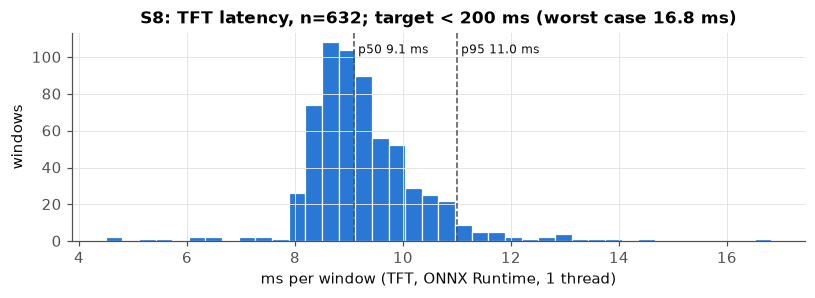

In [7]:
payloads, meta = H.load_demo_payloads()
eng_pl, outs_pl, rec_pl = H.run_engine(payloads, record_tft=True)
feeds = [c[0] for c in rec_pl.calls]
ms = H.time_tft_onnx(feeds, n_min=300)
p50, p95, mx = np.percentile(ms, 50), np.percentile(ms, 95), ms.max()
print(f"[MEASURED loopback, this laptop, 1 thread] TFT ONNX single-window inference over n={len(ms)} real windows: "
      f"p50 {p50:.2f} ms, p95 {p95:.2f} ms, max {mx:.2f} ms  (S8 target < 200 ms)")
fig, ax = plt.subplots(figsize=(7.5, 2.8))
ax.hist(ms, bins=40, color=H.PAL[0], edgecolor="white", linewidth=0.8)
for v, lab in [(p50, "p50"), (p95, "p95")]:
    ax.axvline(v, color=H.INK2, lw=1, ls="--"); ax.text(v, ax.get_ylim()[1] * 0.9, f" {lab} {v:.1f} ms", color=H.INK, fontsize=8)
ax.set_xlabel("ms per window (TFT, ONNX Runtime, 1 thread)"); ax.set_ylabel("windows")
ax.set_title(f"S8: TFT latency, n={len(ms)}; target < 200 ms (worst case {mx:.1f} ms)")
plt.tight_layout(); plt.show()
assert mx < 200, "S8 violated"
H.record("S8", "MET", "9 live / 7 saved",
         f"p50 {p50:.1f} / p95 {p95:.1f} / max {mx:.1f} ms over {len(ms)} single-window TFT ONNX calls (1 thread) [MEASURED loopback]")
H.ITEMS["S8"].section = "4"

### 4b. The hybrid as a whole: N-HiTS inference and the full per-window cost

S8 is worded for the classifier ("fault-classification inference < 200 ms/window — TFT"), so the cell above is the S8 verdict.
The engine is hybrid, though: every window also runs **N-HiTS** (health-index forecast → RUL), plus feature engineering and the RUL step.
Below: (1) `models/nhits.onnx` timed the same way as the TFT (fresh 1-thread session, the real N-HiTS tensors the engine built on the
held-out replay, batch 1); (2) the complete per-window breakdown the `HybridEngine` itself measures (features + TFT + N-HiTS + RUL),
over every post-warm-up window of both bearings. Both are held to the same < 200 ms per-window bound as supporting evidence.

In [8]:
eng_h, outs_h, _ = H.run_engine(payloads, record_nhits=True)
nh_feeds = [c[0] for c in eng_h.rec_nhits.calls]
ms_nh = H.time_onnx("nhits.onnx", ["hi_forecast"], nh_feeds, n_min=300)
print(f"[MEASURED loopback, this laptop, 1 thread] N-HiTS ONNX single-window inference over n={len(ms_nh)} real windows: "
      f"p50 {np.percentile(ms_nh, 50):.2f} ms, p95 {np.percentile(ms_nh, 95):.2f} ms, max {ms_nh.max():.2f} ms")

hyb = pd.concat([H.engine_frame(outs_h, b).assign(bearing=b) for b in (1, 2)])
hyb = hyb[hyb.status == "ok"]
rows = []
for col, name in [("lat_feat", "feature engineering"), ("lat_tft", "TFT (classification)"),
                  ("lat_nhits", "N-HiTS (HI forecast)"), ("lat_total", "TOTAL hybrid per window (features+TFT+N-HiTS+RUL)")]:
    v = hyb[col].to_numpy()
    rows.append({"stage": name, "n": len(v), "p50 ms": round(float(np.percentile(v, 50)), 2),
                 "p95 ms": round(float(np.percentile(v, 95)), 2), "max ms": round(float(v.max()), 2)})
hyb_tab = pd.DataFrame(rows)
display(hyb_tab.style.hide(axis="index"))
tot95, totmax = hyb_tab.iloc[-1]["p95 ms"], hyb_tab.iloc[-1]["max ms"]
frac = float((hyb["lat_total"] < 200).mean())
assert tot95 < 200, f"hybrid per-window p95 {tot95} ms exceeds 200 ms"
print(f"[MEASURED loopback, this laptop] full hybrid per window (Python reference engine): p95 {tot95} ms, max {totmax} ms; "
      f"{frac:.1%} of {len(hyb)} windows < 200 ms")
n_over = int((hyb["lat_total"] >= 200).sum())
print(f"Note: {n_over} of {len(hyb)} windows took >= 200 ms in this notebook process (seen at ~240-260 ms in every notebook run so far; "
      "standalone runs of the same engine gave max 24-166 ms). The time falls outside the model calls (feature arithmetic / interpreter "
      "pauses in this long-lived Python process): timed alone, the ONNX calls stay at TFT max ~20 ms and N-HiTS max ~14 ms. The DEPLOYED path is the C# backend: its measured host leg (UDP packet in -> "
      "dashboard client, which includes features + TFT + N-HiTS + RUL) is p95 ~30 ms, max 36-61 ms across runs (section 8).")
H.ITEMS["S8"].evidence += (f" | Hybrid (supporting): N-HiTS ONNX p95 {np.percentile(ms_nh, 95):.1f} ms; full per-window "
                           f"features+TFT+N-HiTS+RUL (Python reference) p95 {tot95} ms, max {totmax} ms, {frac:.1%} < 200 ms, live; "
                           f"deployed C# host leg incl. both models max 36-61 ms (section 8)")

[MEASURED loopback, this laptop, 1 thread] N-HiTS ONNX single-window inference over n=632 real windows: p50 0.44 ms, p95 0.81 ms, max 2.46 ms


stage,n,p50 ms,p95 ms,max ms
feature engineering,632,0.990000,1.470000,226.440000
TFT (classification),632,10.650000,12.940000,17.090000
N-HiTS (HI forecast),632,0.860000,1.320000,2.940000
TOTAL hybrid per window (features+TFT+N-HiTS+RUL),632,13.360000,16.180000,240.900000


[MEASURED loopback, this laptop] full hybrid per window (Python reference engine): p95 16.18 ms, max 240.9 ms; 99.8% of 632 windows < 200 ms
Note: 1 of 632 windows took >= 200 ms in this notebook process (seen at ~240-260 ms in every notebook run so far; standalone runs of the same engine gave max 24-166 ms). The time falls outside the model calls (feature arithmetic / interpreter pauses in this long-lived Python process): timed alone, the ONNX calls stay at TFT max ~20 ms and N-HiTS max ~14 ms. The DEPLOYED path is the C# backend: its measured host leg (UDP packet in -> dashboard client, which includes features + TFT + N-HiTS + RUL) is p95 ~30 ms, max 36-61 ms across runs (section 8).


## 5. Raw vibration to prediction, end to end (centrepiece)

Held-out test bearings from `splits.json` (never used for training, early stopping, model selection or calibration):

In [9]:
splits = json.loads((H.AIENGINE / "splits.json").read_text())["sections"]
xj = splits["xjtu_sy"]["units"]
print("XJTU-SY test bearings :", [u for u, s in xj.items() if s == "test"])
print("XJTU-SY val bearings  :", [u for u, s in xj.items() if s == "val"])
print("IMS                   :", splits["ims"]["units"])
assert xj["xjtu_sy:Bearing2_5"] == "test" and xj["xjtu_sy:Bearing3_4"] == "test"

XJTU-SY test bearings : ['xjtu_sy:Bearing1_4', 'xjtu_sy:Bearing2_5', 'xjtu_sy:Bearing3_4']
XJTU-SY val bearings  : ['xjtu_sy:Bearing1_3', 'xjtu_sy:Bearing2_2', 'xjtu_sy:Bearing3_5']
IMS                   : {'ims:test1:B1': 'ft_train', 'ims:test1:B2': 'ft_train', 'ims:test1:B3': 'ft_train', 'ims:test1:B4': 'ft_test'}


**Step 1, raw to features.** Read **every** raw snapshot CSV of `Bearing2_5` (outer-race failure, 339 snapshots at
1 per minute, 25.6 kHz, 2 axes) and the first 339 of `Bearing3_4` (healthy phase), cut the first 20-revolution
window, and run COE components 3 to 7 (band-pass 2 to 8 kHz, rectify, envelope, 4096-point order spectrum, 8 features
per axis). Then encode the 152-byte COE payloads and compare them **byte for byte** with `demo_payloads.bin`, the stream
the backend replays.

In [10]:
t0 = time.perf_counter()
F1 = H.raw_bearing_features(files_b1, rpm_b1)
F2 = H.raw_bearing_features(files_b2, rpm_b2, n=len(F1))
t_dsp = time.perf_counter() - t0
raw_payloads = H.build_payloads(F1, F2, rpm_b1)
same = sum(a == b for a, b in zip(raw_payloads, payloads))
print(f"[MEASURED on XJTU-SY] DSP on {len(F1)} + {len(F2)} raw snapshots in {t_dsp:.1f} s "
      f"({1000 * t_dsp / (len(F1) + len(F2)):.1f} ms per bearing-window, Python reference DSP)")
print(f"payloads identical to demo_payloads.bin: {same}/{len(payloads)} (byte-for-byte, 152 B each)")
assert len(raw_payloads) == len(payloads) == same, "raw path does not reproduce the replay stream"

[MEASURED on XJTU-SY] DSP on 339 + 339 raw snapshots in 32.4 s (47.8 ms per bearing-window, Python reference DSP)
payloads identical to demo_payloads.bin: 339/339 (byte-for-byte, 152 B each)


**Step 2, stream through the hybrid engine** (ONNX Runtime, the same models and contract the C# backend loads).
Bearing 1 is the failing bearing; bearing 2 is a healthy stream. Ground truth `[CITED: models/demo_payloads.json,
labels from aiengine/labels.py]`; the RUL truth is re-derived here from the file count (one snapshot per minute).

bearing 1 = xjtu_sy:Bearing2_5 (outer_race), life 5.65 h, labelled onset window 120 (t = 2.00 h); engine ready from window 23
engine's causal onset detector fired at window 131 (t = 2.18 h)
bearing 2 (healthy stream): 0 non-healthy calls out of 316 ready windows


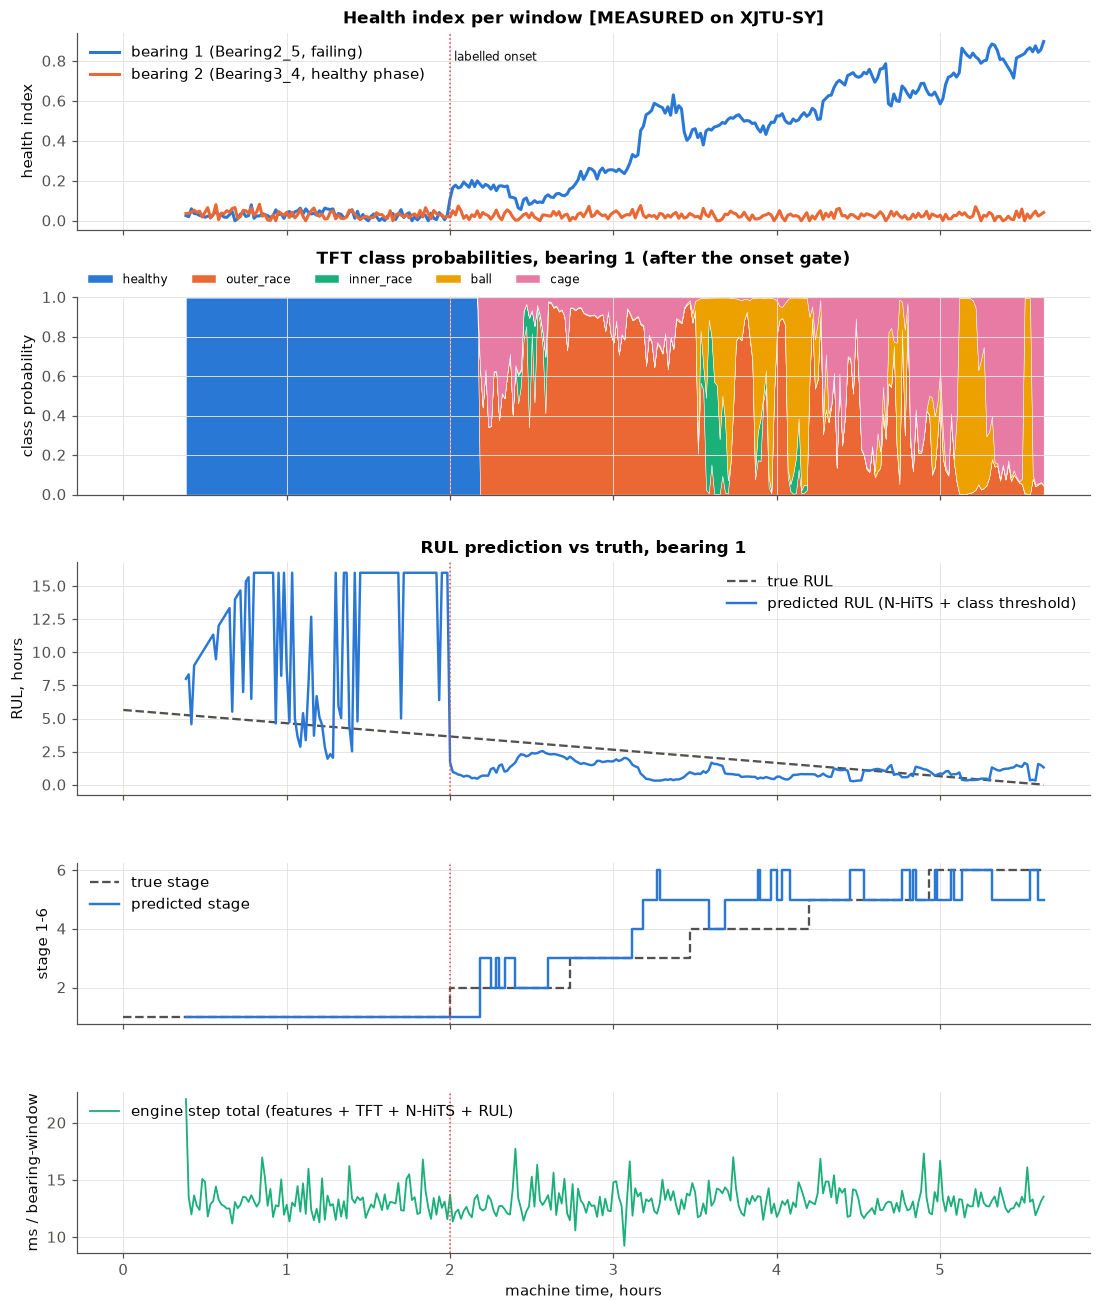

[MEASURED on XJTU-SY] engine step latency p50 13.0 ms, p95 15.3 ms, max 22.1 ms (n=316)
[MEASURED on XJTU-SY] post-onset windows called outer_race: 49%; class mix {'outer_race': 107, 'cage': 58, 'ball': 38, 'healthy': 11, 'inner_race': 5}
[MEASURED on XJTU-SY] this stream's RUL error over the S7 window: 47.3 % (one bearing, causal engine replay; the pre-registered S7 score over all 4 test bearings is in section 6)


In [11]:
eng5, outs5, rec5 = H.run_engine(raw_payloads, record_tft=True)
d1, d2 = H.engine_frame(outs5, 1), H.engine_frame(outs5, 2)
truth = meta["bearing_1"]["truth_per_window"]
life_h = len(files_b1) / 60.0
d1["rul_true"] = life_h - d1["t_h"]
assert np.allclose(d1["rul_true"], truth["rul_hours"], atol=1e-3), "RUL truth mismatch"
d1["stage_true"] = truth["health_stage"]; d1["class_true"] = truth["observable_class"]
onset_i = meta["bearing_1"]["onset_window_index"]; t_on = d1["t_h"][onset_i]
ok1 = d1[d1.status == "ok"]
print(f"bearing 1 = {meta['bearing_1']['unit_id']} ({meta['bearing_1']['fault_class']}), life {life_h:.2f} h, "
      f"labelled onset window {onset_i} (t = {t_on:.2f} h); engine ready from window {ok1.i.min()}")
first_det = ok1[ok1.onset == True].i.min()
print(f"engine's causal onset detector fired at window {first_det} (t = {d1.t_h[first_det]:.2f} h)")
print(f"bearing 2 (healthy stream): {int((d2.pred.fillna('healthy') != 'healthy').sum())} non-healthy calls out of {int((d2.status=='ok').sum())} ready windows")

fig, ax = plt.subplots(5, 1, figsize=(10, 12), sharex=True, gridspec_kw={"height_ratios": [1.1, 1.1, 1.3, 0.9, 0.9]})
x = d1["t_h"]
ax[0].plot(x, d1.hi, color=H.PAL[0], label="bearing 1 (Bearing2_5, failing)")
ax[0].plot(d2["t_h"], d2.hi, color=H.PAL[1], label="bearing 2 (Bearing3_4, healthy phase)")
ax[0].set_ylabel("health index"); ax[0].legend(loc="upper left"); ax[0].set_title("Health index per window [MEASURED on XJTU-SY]")
P = ok1[[f"p_{c}" for c in H.CLASSES]].to_numpy().T
ax[1].stackplot(ok1.t_h, P, colors=[H.CLASS_COLOR[c] for c in H.CLASSES], labels=H.CLASSES, edgecolor="white", linewidth=0.3)
ax[1].set_ylabel("class probability"); ax[1].set_ylim(0, 1)
ax[1].legend(loc="lower left", bbox_to_anchor=(0, 1.0), ncol=5, fontsize=8)
ax[1].set_title("TFT class probabilities, bearing 1 (after the onset gate)", pad=22)
ax[2].plot(x, d1.rul_true, color=H.INK2, lw=1.5, ls="--", label="true RUL")
ax[2].plot(ok1.t_h, ok1.rul, color=H.PAL[0], lw=1.6, label="predicted RUL (N-HiTS + class threshold)")
ax[2].set_ylabel("RUL, hours"); ax[2].legend(loc="upper right"); ax[2].set_title("RUL prediction vs truth, bearing 1")
ax[3].step(x, d1.stage_true, where="post", color=H.INK2, ls="--", lw=1.5, label="true stage")
ax[3].step(ok1.t_h, ok1.stage, where="post", color=H.PAL[0], lw=1.6, label="predicted stage")
ax[3].set_ylabel("stage 1-6"); ax[3].legend(loc="upper left")
ax[4].plot(ok1.t_h, ok1.lat_total, color=H.PAL[2], lw=1.2, label="engine step total (features + TFT + N-HiTS + RUL)")
ax[4].set_ylabel("ms / bearing-window"); ax[4].legend(loc="upper left"); ax[4].set_xlabel("machine time, hours")
for a in ax:
    a.axvline(t_on, color=H.PAL[7], lw=1, ls=":")
ax[0].text(t_on, ax[0].get_ylim()[1] * 0.85, " labelled onset", color=H.INK, fontsize=8)
plt.tight_layout(); plt.show()

post = ok1[ok1.i >= onset_i]
lat = ok1.lat_total.to_numpy()
on_d = ok1[(ok1.t_h >= t_on) & (ok1.t_h <= life_h - 0.1 * (life_h - t_on)) & (ok1.rul_true > 0)]
mape_stream = float(np.mean(np.abs(on_d.rul - on_d.rul_true) / on_d.rul_true) * 100)
print(f"[MEASURED on XJTU-SY] engine step latency p50 {np.percentile(lat, 50):.1f} ms, p95 {np.percentile(lat, 95):.1f} ms, max {lat.max():.1f} ms (n={len(lat)})")
print(f"[MEASURED on XJTU-SY] post-onset windows called outer_race: {(post.pred == 'outer_race').mean():.0%}; "
      f"class mix {post.pred.value_counts().to_dict()}")
print(f"[MEASURED on XJTU-SY] this stream's RUL error over the S7 window: {mape_stream:.1f} % "
      "(one bearing, causal engine replay; the pre-registered S7 score over all 4 test bearings is in section 6)")

**Interpretability (why TFT).** The TFT's variable-selection network gives a weight to every engineered input for the
current window. These are the weights the engine returned for one late, post-onset window of bearing 1. The engine's
`top_features` field (the top 5 sent to the dashboard) is checked against them.

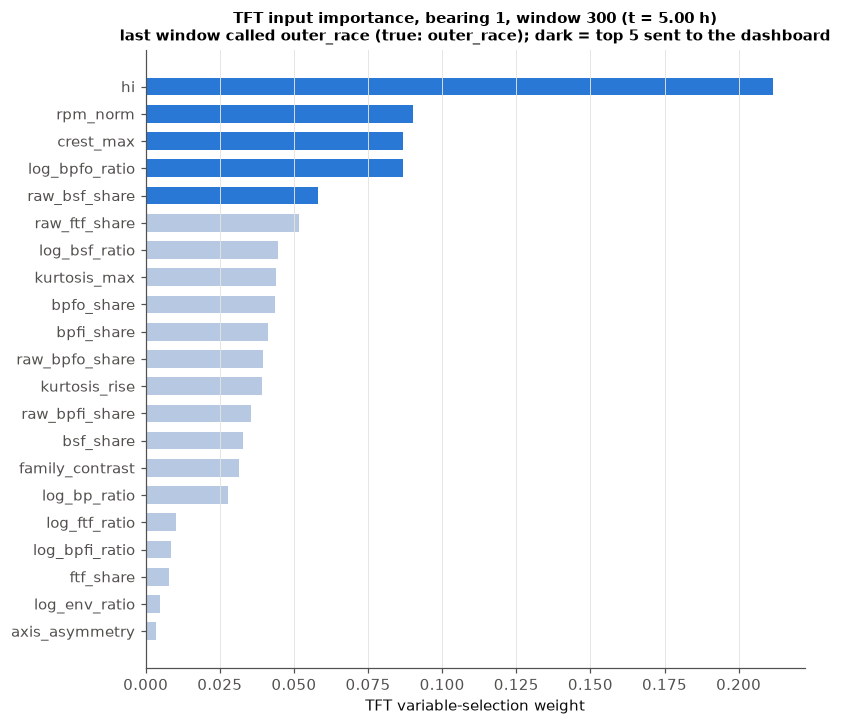

engine top_features (sent to the dashboard): [['hi', 0.2117], ['rpm_norm', 0.0903], ['crest_max', 0.0868], ['log_bpfo_ratio', 0.0868], ['raw_bsf_share', 0.0582]]


In [12]:
calls = rec5.calls
assert len(calls) == 2 * int((d1.status == "ok").sum()), "unexpected TFT call pattern"
# Window shown: the LAST window the TFT called correctly (outer_race). Chosen for illustration, stated as such;
# the per-window accuracy on this stream is printed in the previous cell.
k_win = int(ok1[ok1.pred == "outer_race"].i.iloc[-1])
j = int(np.flatnonzero(ok1.i.to_numpy() == k_win)[0])
vw = calls[2 * j][1][1][0]                        # bearing-1 call, output 'variable_weights'
imp = pd.Series(vw, index=eng5.tcols).sort_values()
top_engine = outs5[k_win]["bearings"][0]["top_features"]
assert [n for n, _ in top_engine] == list(imp.index[::-1][:5]), "engine top_features disagree with the TFT weights"
fig, ax = plt.subplots(figsize=(7.5, 0.28 * len(imp) + 0.8))
ax.barh(imp.index, imp.values, color=[H.PAL[0] if n in dict(top_engine) else "#b7c9e2" for n in imp.index], height=0.65)
ax.set_xlabel("TFT variable-selection weight"); ax.grid(axis="y", visible=False)
t1 = f"TFT input importance, bearing 1, window {k_win} (t = {d1.t_h[k_win]:.2f} h)"
t2 = f"last window called {outs5[k_win]['bearings'][0]['fault_class']} (true: outer_race); dark = top 5 sent to the dashboard"
ax.set_title(t1 + chr(10) + t2, fontsize=9.5)
plt.tight_layout(); plt.show()
print("engine top_features (sent to the dashboard):", top_engine)

## 6. S7: RUL MAPE ≤ 15 % (N-HiTS), pre-registered metric

DESIGN.md section 7 (written before any test result existed): degradation window
**[t_onset, T_fail − 0.1·(T_fail − t_onset)]**; per-bearing mean of |RUL_pred − RUL_true| / RUL_true; MAPE = mean over the
held-out test bearings. Re-scored here **from the stored per-window predictions** with an independent implementation
(the window is rebuilt from `onset_t_hours` and `life_hours`; the stored `in_deg` flag is only used to cross-check).
The predictions themselves come from `app.py evaluate --run real_v2` `[CITED: reports/spec_check_20261005T012112Z_real_v2.json]`.

In [13]:
R2 = pd.read_csv(H.REPORTS / f"{H.V2_TAG}.rul_preds.csv.gz")
R1 = pd.read_csv(H.REPORTS / f"{H.V1_TAG}.rul_preds.csv.gz")
J2, J1 = H.load_report(H.V2_TAG), H.load_report(H.V1_TAG)
s7_v2, per_v2, mask_v2 = H.s7_independent(R2)
s7_v1, per_v1, _ = H.s7_independent(R1)
agree = float((mask_v2 == (R2["in_deg"] & (R2["rul_true"] > 0))).mean())
print(f"window mask agreement with stored in_deg flag: {agree:.4f} ({int(mask_v2.sum())} windows)")
for tag, mine, J in [("v2", s7_v2, J2), ("v1", s7_v1, J1)]:
    stored = J["metrics"]["rul"]["S7_mape_pct"]
    assert abs(mine - stored) < 1e-6, f"{tag}: independent {mine} != report {stored}"
    print(f"{tag}: independent S7 = {mine:.2f} %   report = {stored:.2f} %   -> match")
tab = pd.DataFrame({"S7 MAPE v2 (%)": per_v2, "S7 MAPE v1 (%)": per_v1}).round(1)
life = R2.groupby("unit_id")[["life_hours", "onset_t_hours"]].first()
tab["life (h)"] = life.life_hours.round(2); tab["onset (h)"] = life.onset_t_hours.round(2)
tab["onset as % of life"] = (100 * life.onset_t_hours / life.life_hours).round(0)
display(tab)
print(f"[MEASURED on XJTU-SY + IMS] S7 (v2 headline) = {s7_v2:.1f} %  vs target <= 15 %  ->  NOT MET")

window mask agreement with stored in_deg flag: 1.0000 (2056 windows)
v2: independent S7 = 281.81 %   report = 281.81 %   -> match
v1: independent S7 = 259.55 %   report = 259.55 %   -> match


,S7 MAPE v2 (%),S7 MAPE v1 (%),life (h),onset (h),onset as % of life
ims:test1:B4,468.6,468.6,827.56,172.72,21.0
xjtu_sy:Bearing1_4,567.2,464.2,2.03,1.32,65.0
xjtu_sy:Bearing2_5,47.3,50.9,5.65,2.00,35.0
xjtu_sy:Bearing3_4,44.1,54.5,25.25,23.62,94.0


[MEASURED on XJTU-SY + IMS] S7 (v2 headline) = 281.8 %  vs target <= 15 %  ->  NOT MET


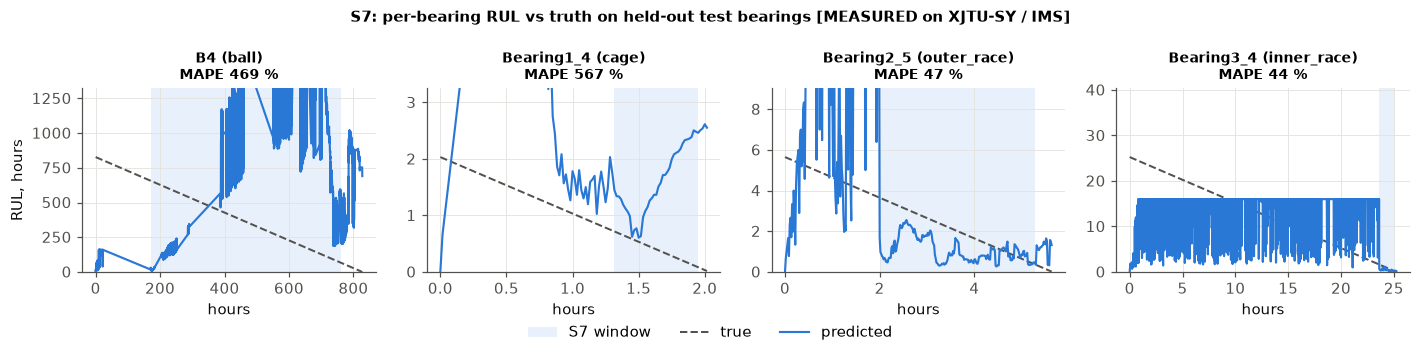

In [14]:
units = list(per_v2)
fig, axs = plt.subplots(1, len(units), figsize=(13, 3.0))
for a, u in zip(axs, units):
    g = R2[R2.unit_id == u].sort_values("t_hours"); m = mask_v2[g.index]
    a.axvspan(g.t_hours[m].min(), g.t_hours[m].max(), color="#e8f0fb", lw=0, label="S7 window")
    a.plot(g.t_hours, g.rul_true, color=H.INK2, ls="--", lw=1.3, label="true")
    a.plot(g.t_hours, g.rul_pred, color=H.PAL[0], lw=1.4, label="predicted")
    a.set_ylim(0, max(g.rul_true.max(), 1) * 1.6)
    a.set_title(f"{u.split(':')[-1]} ({g.fault_class.iloc[0]})\nMAPE {per_v2[u]:.0f} %", fontsize=9)
    a.set_xlabel("hours")
axs[0].set_ylabel("RUL, hours")
fig.legend(*axs[0].get_legend_handles_labels(), loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.06))
fig.suptitle("S7: per-bearing RUL vs truth on held-out test bearings [MEASURED on XJTU-SY / IMS]", fontweight="bold", fontsize=10)
plt.tight_layout(); plt.show()

**Secondary robustness check** `[CITED: reports/model_selection_robustness_lobo_20261004T214321Z.json]`,
leave-one-bearing-out over all 15 XJTU-SY bearings (v1 models, retrained 15 times; hours of CPU, so loaded, not re-run).
Not the pre-registered headline. The life spread is recomputed live from the feature cache.

In [15]:
lobo = json.loads((H.REPORTS / H.LOBO_JSON).read_text())
L = pd.DataFrame(lobo["folds"])[["unit_id", "fault_class", "frozen_split", "S7_mape_pct"]].set_index("unit_id")
L["S7_mape_pct"] = L["S7_mape_pct"].round(1)
med, mean = L.S7_mape_pct.median(), L.S7_mape_pct.mean()
assert abs(med - lobo["median_S7_mape_pct"]) < 0.06
display(L.sort_values("S7_mape_pct").T)
print(f"[CITED: LOBO json] median {med:.1f} %, mean {mean:.1f} %, bearings <= 15 %: {(L.S7_mape_pct <= 15).sum()}/{len(L)}")
cache = pd.read_parquet(DATA / "cache" / "xjtu_sy.parquet", columns=["unit_id", "life_hours"]).groupby("unit_id").life_hours.first()
print(f"[MEASURED on XJTU-SY] life spread across the 15 bearings: {cache.min():.2f} h to {cache.max():.2f} h "
      f"({cache.max() / cache.min():.0f}x); same rig, same load class, same bearing type")
H.record("S7", "NOT MET", "9 live re-score / 6 stored preds",
         f"{s7_v2:.1f} % vs <= 15 % (per bearing {', '.join(f'{u.split(chr(58))[-1]} {v:.0f} %' for u, v in per_v2.items())}); "
         f"LOBO median {med:.0f} %. Independent re-score = report")
H.ITEMS["S7"].section = "6"

unit_id,xjtu_sy:Bearing2_4,xjtu_sy:Bearing2_1,xjtu_sy:Bearing3_1,xjtu_sy:Bearing3_4,xjtu_sy:Bearing2_5,xjtu_sy:Bearing1_2,xjtu_sy:Bearing3_3,xjtu_sy:Bearing2_2,xjtu_sy:Bearing2_3,xjtu_sy:Bearing1_3,xjtu_sy:Bearing1_1,xjtu_sy:Bearing1_5,xjtu_sy:Bearing1_4,xjtu_sy:Bearing3_5,xjtu_sy:Bearing3_2
fault_class,outer_race,inner_race,outer_race,inner_race,outer_race,outer_race,inner_race,outer_race,cage,outer_race,outer_race,mixed,cage,outer_race,mixed
frozen_split,train,train,train,test,test,train,train,val,train,val,train,train,test,val,train
S7_mape_pct,27.1,32.6,46.7,64.6,68.5,71.0,72.6,73.7,79.7,82.7,96.8,153.7,569.9,711.7,1174.4


[CITED: LOBO json] median 73.7 %, mean 221.7 %, bearings <= 15 %: 0/15
[MEASURED on XJTU-SY] life spread across the 15 bearings: 0.70 h to 42.30 h (60x); same rig, same load class, same bearing type


**Why S7 fails, plainly.**
- **Life spread.** Bearings of the same type, under the same load class, live from minutes to tens of hours (computed above).
  Once degradation starts, how long it will last is weakly determined by the vibration features seen so far: the
  two bearings with short, abrupt failures (`Bearing1_4`, cage, about 2 h total; `IMS B4`, long plateau) carry most of the error,
  while the two with a progressive trend (`Bearing2_5`, `Bearing3_4`) sit at 44 to 47 %.
- **Information floor.** A per-window percentage error in hours divides by RUL_true, which goes to zero near failure.
  The earlier synthetic testbench (`AI-test`) showed a floor of about 32 % for *any* forecaster under absolute-hours
  MAPE when life varies 2.5x; real data varies far more.
- **No rig run-to-failure data yet.** The models are trained on public test rigs only. Fine-tuning on the team's
  own commissioning and degradation data is the planned step; the IMS rehearsal shows the mechanics but not the gain.

**Levers.** (1) Rig run-to-failure or accelerated-degradation data, then fine-tune. (2) The **percent-of-life framing**
is a *team decision* that changes the spec's wording; it is not applied here, because silently redefining the metric
is not allowed. The pre-registered number stays the headline.

## 7. IS3: macro-F1 ≥ 0.85 over {healthy, outer race, inner race, ball, cage}; stage error ≤ 1; caught by stage 3

Re-scored live from the stored per-window test predictions `[CITED: reports/*_real_v2.tft_preds.csv.gz, v1 = *_real.tft_preds.csv.gz]`,
then asserted equal to the stored reports. **Disclosure:** v2 is the *second look* at the XJTU-SY / IMS test bearings
(v1 was scored first). Every v2 choice was made on validation data only (`reports/model_selection_tft_v2_20261005T011306Z.json`),
but a second look is still a second look. MaFaulDa test records were scored once.

In [16]:
T2 = pd.read_csv(H.REPORTS / f"{H.V2_TAG}.tft_preds.csv.gz")
T1 = pd.read_csv(H.REPORTS / f"{H.V1_TAG}.tft_preds.csv.gz")
m2, m1 = H.is3_independent(T2, R2), H.is3_independent(T1, R1)
for tag, m, J in [("v2", m2, J2), ("v1", m1, J1)]:
    c = J["metrics"]["classification"]; r = J["metrics"]["rul"]; dct = J["metrics"]["detection"]
    assert abs(m["macro_f1_5"] - c["macro_f1_all5"]) < 1e-9, (tag, m["macro_f1_5"], c["macro_f1_all5"])
    for ds, v in m["per_dataset"].items():
        assert abs(v["macro_f1"] - c["per_dataset"][ds]["macro_f1"]) < 1e-9, (tag, ds)
    assert m["stage"]["max"] == r["stage_max_error"] and abs(m["stage"]["within1"] - r["stage_within1_frac"]) < 1e-9
    assert abs(m["caught_frac"] - dct["caught_by_stage3_frac"]) < 1e-9, (tag, m["caught_frac"], dct["caught_by_stage3_frac"])
    print(f"{tag}: independent re-score matches the stored report (macro-F1, per-dataset F1, stage error, caught-by-stage-3)")

rows = []
for tag, m in [("v1 (XJTU-SY-only TFT, 4 channels)", m1), ("v2 (joint XJTU-SY + IMS + MaFaulDa TFT)", m2)]:
    rows.append({"model": tag, "test windows": m["n"], "IS3a macro-F1 (5 classes)": round(m["macro_f1_5"], 3),
                 **{f"F1 {ds}": round(v["macro_f1"], 3) for ds, v in m["per_dataset"].items()},
                 "IS3b max stage error": m["stage"]["max"], "mean stage error": round(m["stage"]["mean"], 2),
                 "within +/-1": f"{m['stage']['within1']:.1%}",
                 "IS3c caught by stage 3": f"{int(m['caught'].caught_by_stage3.sum())}/{len(m['caught'])}"})
display(pd.DataFrame(rows).set_index("model").T)
display(Markdown("**Per-class F1, v2:** " + ", ".join(f"{c} {m2['per_class_f1'][c]:.3f} (n={m2['support'][c]})" for c in H.CLASSES)))
display(m2["caught"])

v2: independent re-score matches the stored report (macro-F1, per-dataset F1, stage error, caught-by-stage-3)
v1: independent re-score matches the stored report (macro-F1, per-dataset F1, stage error, caught-by-stage-3)


model,"v1 (XJTU-SY-only TFT, 4 channels)",v2 (joint XJTU-SY + IMS + MaFaulDa TFT)
test windows,4124,5569
IS3a macro-F1 (5 classes),0.288,0.581
F1 ims,0.089,0.679
F1 xjtu_sy,0.565,0.45
IS3b max stage error,4,4
mean stage error,0.9,0.9
within +/-1,72.1%,72.1%
IS3c caught by stage 3,2/4,1/4
F1 mafaulda,NaN,0.848


**Per-class F1, v2:** healthy 0.985 (n=1909), outer_race 0.759 (n=685), inner_race 0.017 (n=98), ball 0.500 (n=2352), cage 0.644 (n=525)

,unit_id,fault_class,caught_at_window,caught_at_stage,caught_by_stage3
0,ims:test1:B4,ball,1679.0,6.0,False
1,xjtu_sy:Bearing1_4,cage,NaN,NaN,False
2,xjtu_sy:Bearing2_5,outer_race,146.0,2.0,True
3,xjtu_sy:Bearing3_4,inner_race,1457.0,4.0,False


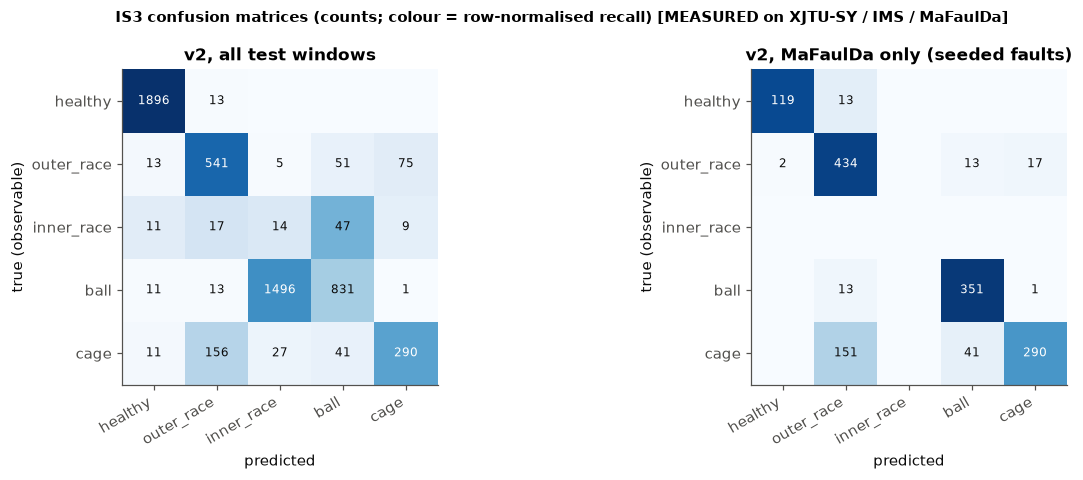

[MEASURED] IS3a overall 0.581 (target >= 0.85) -> NOT MET. MaFaulDa (seeded faults, 8-ball bearing like the rig, wide speed range) 0.848; XJTU-SY 0.450; IMS 0.679
[MEASURED on MaFaulDa] speed range of the records: 714 to 3723 rpm


In [17]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4.4))
cm = m2["confusion"].astype(float)
for a, M, title in [(axs[0], cm, "v2, all test windows"),
                    (axs[1], H.is3_independent(T2[T2.dataset == "mafaulda"], None)["confusion"].astype(float), "v2, MaFaulDa only (seeded faults)")]:
    rn = M / np.maximum(M.sum(1, keepdims=True), 1)
    a.imshow(rn, cmap="Blues", vmin=0, vmax=1)
    for i in range(5):
        for k in range(5):
            if M[i, k] > 0:
                a.text(k, i, f"{int(M[i, k])}", ha="center", va="center", fontsize=8,
                       color="white" if rn[i, k] > 0.55 else H.INK)
    a.set_xticks(range(5), H.CLASSES, rotation=30, ha="right"); a.set_yticks(range(5), H.CLASSES)
    a.set_xlabel("predicted"); a.set_ylabel("true (observable)"); a.grid(False); a.set_title(title)
fig.suptitle("IS3 confusion matrices (counts; colour = row-normalised recall) [MEASURED on XJTU-SY / IMS / MaFaulDa]",
             fontweight="bold", fontsize=10)
plt.tight_layout(); plt.show()
mf = m2["per_dataset"]["mafaulda"]
print(f"[MEASURED] IS3a overall {m2['macro_f1_5']:.3f} (target >= 0.85) -> NOT MET. "
      f"MaFaulDa (seeded faults, 8-ball bearing like the rig, wide speed range) {mf['macro_f1']:.3f}; "
      f"XJTU-SY {m2['per_dataset']['xjtu_sy']['macro_f1']:.3f}; IMS {m2['per_dataset']['ims']['macro_f1']:.3f}")
rpm_rng = pd.read_parquet(DATA / "cache" / "mafaulda.parquet", columns=["rpm"]).rpm
print(f"[MEASURED on MaFaulDa] speed range of the records: {rpm_rng.min():.0f} to {rpm_rng.max():.0f} rpm")
H.record("IS3", "NOT MET", "9 live re-score / 6 stored preds",
         f"macro-F1 {m2['macro_f1_5']:.3f} (MaFaulDa {mf['macro_f1']:.3f}); max stage error {m2['stage']['max']} "
         f"({m2['stage']['within1']:.0%} within +/-1); caught by stage 3 {int(m2['caught'].caught_by_stage3.sum())}/{len(m2['caught'])}")
H.ITEMS["IS3"].section = "7"

**Reading.** IS3 **fails** overall. On MaFaulDa, the dataset closest to the rig (seeded faults, an 8-ball bearing,
a wide speed range), macro-F1 is close to the target. The main failure is a **source shortcut** validation could not
see: IMS `B4` ball windows are called inner race (the only IMS-domain fault in training is `B3`'s inner race), and XJTU-SY
cage and inner race stay weak. Next lever: domain-balanced training or per-dataset normalisation of the order-band
shares, scored on a fresh untouched test set, and then fine-tuning on rig seeded-fault data.

## 8. S9 (dashboard ≥ 10 Hz) and IS1 (sensor to dashboard < 500 ms), live

The backend is started **from its Release build** in a subprocess, with the real ONNX models in the loop, and measured
by `tools/DemoMeasure`, a SignalR client that subscribes to the hub exactly like the Blazor dashboard does.
- **S9**: replay of the held-out XJTU-SY stream at 10 payloads/s; count snapshots received by the client for 10 s.
- **IS1 (host leg)**: replay off; DemoMeasure sends each of the 339 payloads over **UDP** (as the ESP32 node will)
  at 20 payloads/s and times UDP send to the matching snapshot arriving at the client.
Each backend is stopped by its own PID at the end of the cell.

In [18]:
LIVE_8 = DOTNET is not None and H.BACKEND_DIR.joinpath("DigitalTwin.Backend.dll").is_file() and H.DEMOMEASURE_DLL.is_file()
if LIVE_8:
    be = H.Backend(replay=True, source="demo", rate_hz=10).start()
    try:
        out_rate = H.demomeasure(["rate", be.url, "10"])
        _, metrics_txt = be.get("/api/metrics")
    finally:
        print(be.stop())
    rate = H.parse_rate(out_rate)
    print("\n".join(out_rate.splitlines()[:6]))
    stages = {s["stage"]: s for s in json.loads(metrics_txt)["stages"]}
    display(pd.DataFrame(stages).T[["count", "p50Ms", "p95Ms", "maxMs"]].round(2))

    be = H.Backend(replay=False).start()   # fresh process; ONNX sessions are warmed up at backend startup
    try:
        out_lat = H.demomeasure(["latency", be.url, str(be.udp), str(H.MODELS / "demo_payloads.bin"), "20"], timeout=240)
    finally:
        print(be.stop())
    lat = H.parse_latency(out_lat)
    print("\n".join(l for l in out_lat.splitlines() if "MEASURED" in l))
    src = "[MEASURED loopback, dev laptop; re-measure on the chosen server]"
else:
    print("dotnet build not available: FALLING BACK to stored measurements [CITED: evidence/integration_measurements_20261005.md]")
    txt = H.stored_integration_measurements(); print(txt[:2500])
    rate = {"hz": 30.0, "per_sec_min": None}
    lat = {"onnx_active": {"n": 303, "p50": 25.1, "p95": 30.0, "max": 39.8}, "all": {"n": 339, "p50": 25.5, "p95": 30.5, "max": 137.5}}   # transcribed from that file
    src = "[CITED: evidence/integration_measurements_20261005.md, stored]"

backend PID 31268 stopped (exit 1); a nonzero exit code is expected here, the process was terminated on purpose by this notebook
MEASURED client snapshot rate: 300 snapshots in 10.00s = 29.99 Hz; inter-arrival p50=33.1 ms p95=57.3 ms max=65.6 ms
MEASURED per-second counts: min=29 max=31 (S9 needs >= 10 Hz)
  t=  0.00s  commissioning | b1=- | b2=-  aiRul=-1.00h hi=0.0% conf=0.0% phys=null resid=null machine=OH2-PUMP-01 [REPLAY: XJTU-SY public data]
  t=  1.13s  Healthy | b1=- | b2=-  aiRul=2.07h hi=3.6% conf=100.0% phys=null resid=null machine=OH2-PUMP-01 [REPLAY: XJTU-SY public data]
snapshots with PhysicsRulHours != null: 0/300; with RulResidualPercent: 0
last: aiRul=4.10 class=Healthy latencyMs(server decode+feat+inf)=26.487


,count,p50Ms,p95Ms,maxMs
broadcast,115,0.067,0.2706,1.5917
decode,115,0.0068,0.019,0.0362
features,115,0.0324,0.1789,40.823
inference,115,23.0861,30.2313,91.713
nhits_onnx,92,1.2483,1.8763,6.9936
tft_onnx,92,22.8782,28.465,57.2309
total_ingest_to_broadcast,115,23.2481,32.6494,133.0414


backend PID 4988 stopped (exit 1); a nonzero exit code is expected here, the process was terminated on purpose by this notebook
MEASURED UDP-send -> client-snapshot latency, ALL n=339: p50=24.60 p95=29.65 max=130.94 ms
MEASURED same, ONNX-active windows only (payload >= 37) n=303: p50=24.83 p95=29.18 max=38.74 ms (IS1 budget 500 ms)


In [19]:
s9_ok = rate["hz"] >= 10 and (rate["per_sec_min"] is None or rate["per_sec_min"] >= 10)
print(f"{src} S9: {rate['hz']:.1f} snapshots/s at the client, worst 1-s window {rate['per_sec_min']} (target >= 10 Hz) -> {'MET' if s9_ok else 'NOT MET'}")
host_p95_all, host_max_all = lat["all"]["p95"], lat["all"]["max"]
host_p95, host_max = lat["onnx_active"]["p95"], lat["onnx_active"]["max"]   # HOST_LEG: ONNX-active windows
cold_start_ms = host_max_all                                                  # one-off first payload after process start
print(f"{src} IS1 host leg (UDP payload in -> decode -> features -> TFT + N-HiTS -> SignalR snapshot at client), warmed-up backend:")
print(f"    ONNX-active windows (n={lat['onnx_active']['n']}): p50 {lat['onnx_active']['p50']:.1f}, p95 {host_p95:.1f}, max {host_max:.1f} ms")
print(f"    all windows (n={lat['all']['n']}): p95 {host_p95_all:.1f} ms; cold-start one-off (first payload after process start) {cold_start_ms:.1f} ms, reported separately")

# ---- IS1 budget parameters (edit here) ----
COE_LEG_MS = 333.0      # COE spec S5 budget (acquisition + DSP of a 20-rev window); replace with COE's measured value when available
COE_LEG_SOURCE = "S5 spec budget (not yet measured)"
COE_LEG_MEASURED = False   # set True only when COE_LEG_MS is a measured value
ME_LEG_MS = 0.0         # the ME side adds no separate processing on this path (the FE twin runs on the host, in parallel). Set if ME reports a leg.
WIFI_HOP_MS = None      # unmeasured; the margin below is what it may use
b = H.is1_budget(COE_LEG_MS, COE_LEG_MEASURED, ME_LEG_MS, host_p95, host_max, WIFI_HOP_MS)
budget_tbl = pd.DataFrame([
    {"leg": f"COE (S5)  [{COE_LEG_SOURCE}]", "p95 case (ms)": COE_LEG_MS, "max case (ms)": COE_LEG_MS},
    {"leg": "ME (no separate leg on this path)", "p95 case (ms)": ME_LEG_MS, "max case (ms)": ME_LEG_MS},
    {"leg": "Host, ONNX-active [MEASURED]", "p95 case (ms)": host_p95, "max case (ms)": host_max},
    {"leg": "TOTAL (COE + ME + host)", "p95 case (ms)": b["tot_p95"], "max case (ms)": b["tot_max"]},
    {"leg": "Margin to 500 ms", "p95 case (ms)": b["margin_p95"], "max case (ms)": b["margin_max"]},
    {"leg": "Allowed Wi-Fi hop budget (500 - total), unmeasured", "p95 case (ms)": b["margin_p95"], "max case (ms)": b["wifi_allowed_ms"]},
]).set_index("leg").round(1)
display(budget_tbl)
print(f"[CALCULATED] IS1: {COE_LEG_MS:.0f} + {ME_LEG_MS:.0f} + {host_max:.1f} (host max) = {b['tot_max']:.1f} ms; "
      f"{b['wifi_allowed_ms']:.0f} ms left for the Wi-Fi hop.  Cold-start one-off (not steady state): {cold_start_ms:.1f} ms alone, "
      f"{COE_LEG_MS + ME_LEG_MS + cold_start_ms:.1f} ms with the COE budget.")
print("IS1 status:", b["status"])
rank8 = "9 live / 7 saved" if src.startswith("[MEASURED") else "7 stored"
H.record("S9", "MET (rate; replay)" if s9_ok else "NOT MET", rank8,
         f"snapshot rate at a SignalR client: {rate['hz']:.1f} Hz on replay data, worst second {rate['per_sec_min']} {src}. "
         "Physics RUL fields are populated only in twin-sim [SIMULATION] mode. The browser render was not verified in this run")
H.record("IS1", b["status"], rank8.replace("9 live", "9 live (host leg)"),
         f"host leg (ONNX-active, warmed-up backend) p95 {host_p95:.1f} / max {host_max:.1f} ms; cold-start one-off {cold_start_ms:.1f} ms {src}; "
         f"{COE_LEG_MS:.0f} ms COE leg [{COE_LEG_SOURCE}] + host max = {b['tot_max']:.1f} ms [CALCULATED]; "
         f"Wi-Fi hop unmeasured, <= {b['wifi_allowed_ms']:.0f} ms allowed")
H.ITEMS["S9"].section = "8, 9"; H.ITEMS["IS1"].section = "8"


[MEASURED loopback, dev laptop; re-measure on the chosen server] S9: 30.0 snapshots/s at the client, worst 1-s window 29 (target >= 10 Hz) -> MET
[MEASURED loopback, dev laptop; re-measure on the chosen server] IS1 host leg (UDP payload in -> decode -> features -> TFT + N-HiTS -> SignalR snapshot at client), warmed-up backend:
    ONNX-active windows (n=303): p50 24.8, p95 29.2, max 38.7 ms
    all windows (n=339): p95 29.6 ms; cold-start one-off (first payload after process start) 130.9 ms, reported separately


,p95 case (ms),max case (ms)
leg,,
COE (S5) [S5 spec budget (not yet measured)],333.0,333.0
ME (no separate leg on this path),0.0,0.0
"Host, ONNX-active [MEASURED]",29.2,38.7
TOTAL (COE + ME + host),362.2,371.7
Margin to 500 ms,137.8,128.3
"Allowed Wi-Fi hop budget (500 - total), unmeasured",137.8,128.3


[CALCULATED] IS1: 333 + 0 + 38.7 (host max) = 371.7 ms; 128 ms left for the Wi-Fi hop.  Cold-start one-off (not steady state): 130.9 ms alone, 463.9 ms with the COE budget.
IS1 status: PARTIAL: CONDITIONAL MET (host leg measured; COE leg at spec budget; Wi-Fi hop unmeasured, <= 128 ms allowed)


In [20]:
lan = H.lan_ipv4s()
lan_txt = ", ".join(f"http://{ip}:5080/" for ip in lan) or "http://<laptop-LAN-IP>:5080/"
display(Markdown(f'''**Live dashboard for the demo (separate from this notebook):** in a PowerShell at the repo root run
`./scripts/run-demo.ps1` (replay of held-out XJTU-SY data, real ONNX models) or `./scripts/run-demo.ps1 -Mode twin-sim`
(`[SIMULATION]` physics twin). Then open **http://localhost:5080/** on this laptop, or
from a phone or another laptop on the same LAN use this laptop's address on the room network
(private IPv4 addresses found now: {lan_txt}; check `ipconfig`, VPN and WSL adapters also appear). C5: a non-private client gets 403.
Switch source without restart: `curl -X POST "http://localhost:5080/api/demo/source?name=twin-sim"`.'''))

**Live dashboard for the demo (separate from this notebook):** in a PowerShell at the repo root run
`./scripts/run-demo.ps1` (replay of held-out XJTU-SY data, real ONNX models) or `./scripts/run-demo.ps1 -Mode twin-sim`
(`[SIMULATION]` physics twin). Then open **http://localhost:5080/** on this laptop, or
from a phone or another laptop on the same LAN use this laptop's address on the room network
(private IPv4 addresses found now: http://10.80.35.246:5080/, http://10.2.0.2:5080/; check `ipconfig`, VPN and WSL adapters also appear). C5: a non-private client gets 403.
Switch source without restart: `curl -X POST "http://localhost:5080/api/demo/source?name=twin-sim"`.

## 9. IS2: physics-AI RUL residual ≤ 5 % `[SIMULATION]`

Two parts. **(a)** The physics twin's stiffness identification (ME spec S2, ≤ 10 % error) re-run live with a reduced
trial count (the full 40-trial table takes about 90 s and is loaded from its stored JSON beside it).
**(b)** The backend in `twin-sim` mode: our synthetic degrading run with FE-beam displacement drives both the AI RUL
(real ONNX models) and the physics RUL; the residual |physics − AI| / AI is read from every snapshot.
Everything here is simulation; the public datasets have no displacement probes, so IS2 cannot be measured on them.

In [21]:
from aiengine.twin import verification as V
t0 = time.perf_counter()
s2_live = pd.DataFrame(V.s2_verification(seed=H.SEED, n_trials=5))
t_s2 = time.perf_counter() - t0
s2_stored = pd.DataFrame(json.loads((H.REPORTS / "twin_s2_verification.json").read_text())["cases"])
cols = ["case", "rpm", "noise", "n_trials", "err_mean_pct", "err_p95_pct", "err_max_pct"]
noisy_live = s2_live[s2_live.noise != "none"][cols].round(2)
noisy_stored = s2_stored[s2_stored.noise != "none"][cols].round(2)
print(f"[SIMULATION] live S2 identification, 5 noisy trials per case, {t_s2:.1f} s; noise-free max error "
      f"{s2_live[s2_live.noise == 'none'].err_max_pct.max():.2e} %")
display(noisy_live.set_index(["case", "rpm"]))
print("[CITED: reports/twin_s2_verification.json, 40 trials per case, seed 20261004]")
display(noisy_stored.set_index(["case", "rpm"]).groupby(level="rpm").agg({"err_mean_pct": ["min", "max"], "err_p95_pct": "max", "err_max_pct": "max"}).round(1))

[SIMULATION] live S2 identification, 5 noisy trials per case, 13.6 s; noise-free max error 7.28e-09 %


noise  n_trials  err_mean_pct  err_p95_pct  err_max_pct
case          rpm                                                                                   
healthy       1750.0  +/-5% amp, +/-0.05 rad phase         5          7.53        14.74        15.51
              3600.0  +/-5% amp, +/-0.05 rad phase         5         24.81        34.48        36.35
K1 -10%       1750.0  +/-5% amp, +/-0.05 rad phase         5          3.70         5.48         5.71
              3600.0  +/-5% amp, +/-0.05 rad phase         5         19.71        32.39        36.00
K2 -15%       1750.0  +/-5% amp, +/-0.05 rad phase         5          6.14         8.34         8.48
              3600.0  +/-5% amp, +/-0.05 rad phase         5         29.94        44.81        47.50
both -20%     1750.0  +/-5% amp, +/-0.05 rad phase         5          5.36        10.30        11.28
              3600.0  +/-5% amp, +/-0.05 rad phase         5         22.28        36.28        38.87
asym -25%/-5% 1750.0  +/-5% amp, +/-0.05 rad phase         5          4.91        10.52        11.61
              3600.0  +/-5% amp, +/-0.05 rad phase         5         13.17        16.28        16.82
K1 -30%       1750.0  +/-5% amp, +/-0.05 rad phase         5          5.35         8.19         8.87
              3600.0  +/-5% amp, +/-0.05 rad phase         5         20.58        24.17        24.72

[CITED: reports/twin_s2_verification.json, 40 trials per case, seed 20261004]


err_mean_pct       err_p95_pct err_max_pct
                min   max         max         max
rpm                                              
1750.0          4.8   6.4        13.6        15.5
3600.0         18.7  24.2        49.7        64.8

backend PID 20232 stopped (exit 1); a nonzero exit code is expected here, the process was terminated on purpose by this notebook


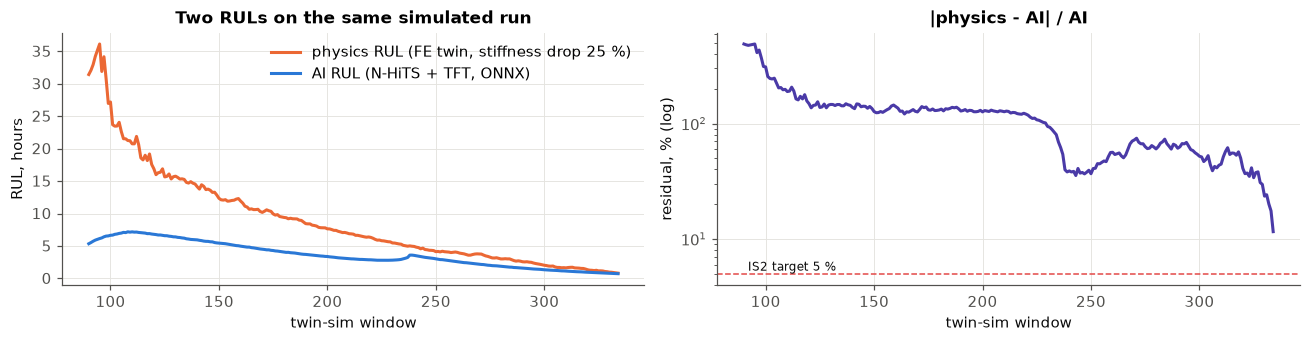

[SIMULATION, live backend] snapshots with both RULs: 244; residual min 12 %, median 124 %, max 488 %; stage 1-3 windows: 55, max residual there 488 %


In [22]:
if LIVE_8:
    be = H.Backend(replay=True, source="twin-sim", rate_hz=40).start()
    try:
        tw = H.poll_state(be, max_payloads=400, timeout_s=40)
    finally:
        print(be.stop())
    src9 = "[SIMULATION, live backend]"
    tw = tw.dropna(subset=["physics_rul_h", "ai_rul_h"])
    tw = tw[tw.ai_rul_h > 0]
    assert len(tw) > 20, f"too few twin-sim snapshots with both RULs ({len(tw)})"
    res = tw.residual_pct
    fig, axs = plt.subplots(1, 2, figsize=(12, 3.2))
    axs[0].plot(tw.payload, tw.physics_rul_h, color=H.PAL[1], label="physics RUL (FE twin, stiffness drop 25 %)")
    axs[0].plot(tw.payload, tw.ai_rul_h, color=H.PAL[0], label="AI RUL (N-HiTS + TFT, ONNX)")
    axs[0].set_xlabel("twin-sim window"); axs[0].set_ylabel("RUL, hours"); axs[0].legend(); axs[0].set_title("Two RULs on the same simulated run")
    axs[1].plot(tw.payload, res, color=H.PAL[6]); axs[1].axhline(5, color=H.PAL[7], ls="--", lw=1)
    axs[1].text(tw.payload.min(), 5, " IS2 target 5 %", va="bottom", fontsize=8, color=H.INK)
    axs[1].set_yscale("log"); axs[1].set_xlabel("twin-sim window"); axs[1].set_ylabel("residual, % (log)")
    axs[1].set_title("|physics - AI| / AI")
    plt.tight_layout(); plt.show()
    st13 = tw[tw.stage.fillna(9) <= 3]
    print(f"{src9} snapshots with both RULs: {len(tw)}; residual min {res.min():.0f} %, median {res.median():.0f} %, max {res.max():.0f} %; "
          f"stage 1-3 windows: {len(st13)}, max residual there {st13.residual_pct.max() if len(st13) else float('nan'):.0f} %")
    is2_txt = f"twin-sim residual median {res.median():.0f} % (min {res.min():.0f} %) vs <= 5 %"
    phys_together = True
else:
    print("dotnet build not available: FALLING BACK [CITED: INTEGRATION.md, IS2 twin-sim]: residual 447 % at first estimate, "
          "125-145 % mid-run, 39 % at the end")
    is2_txt, src9, phys_together = "stored twin-sim residual 39-447 % vs <= 5 %", "[CITED: INTEGRATION.md]", False
H.record("IS2", "NOT MET", "9 live (simulation)" if LIVE_8 else "6 stored simulation",
         f"{is2_txt} {src9}. The two RULs do not yet share a failure definition or time base; S2 identification "
         f"(ME) holds at 1750 rpm on the mean, not at 3600 rpm")
H.ITEMS["IS2"].section = "9"

**IS2 is NOT met.** In simulation the physics RUL (stiffness trend to a 25 % drop) and the AI RUL (health-index forecast
to a class threshold) disagree by far more than 5 %. They are two independent estimators with different failure
definitions and time bases, and the physics twin's own RUL error is 11 to 24 % in simulation (`aiengine/twin/README.md`),
so 5 % agreement is not reachable until the team fixes one failure definition and the ME rotor model replaces the assumed geometry.

## 10. ONNX / C# parity

The same `golden_vectors.json` (12 windows of a held-out bearing with every intermediate) is replayed by:
the **C# backend** (`GoldenParityTests`) and the C# twin parity tests, run live with `dotnet test`; the **Python
engine** (ONNX Runtime); and the **PyTorch checkpoint** versus the exported ONNX graph.

In [23]:
if DOTNET is None:
    raise RuntimeError("dotnet SDK not on PATH: C# parity cannot run live")
RUN_SLOW_TWIN_SEQUENCE = False   # Twin_sequence_matches_python replays a whole twin run (~55 s); set True to include it
flt = "FullyQualifiedName~GoldenParity|FullyQualifiedName~Params_match_python|FullyQualifiedName~Forward_model_matches_python|FullyQualifiedName~Identification_matches_python"
if RUN_SLOW_TWIN_SEQUENCE:
    flt += "|FullyQualifiedName~Twin_sequence_matches_python"
summary, tot = H.dotnet_test(flt, project="DigitalTwin.slnx")
print(summary)
print(f"\n[MEASURED] dotnet test (golden + twin parity): {tot}")
assert tot["failed"] == 0 and tot["passed"] >= 1
gp = H.golden_python_parity()
print(f"\n[MEASURED] Python HybridEngine vs golden_vectors.json: {gp}")
assert gp["max_abs_prob_diff"] < 1e-4 and gp["max_rel_rul_diff"] < 1e-3
if CKPT is not None:
    tp = H.torch_onnx_parity(CKPT)
    print(f"[MEASURED] PyTorch TFT checkpoint vs tft.onnx on the golden tensors: {tp}")
    assert tp["max_abs_logit_diff"] < 1e-4
else:
    print("PyTorch checkpoint not found (checkpoints are git-ignored): torch-vs-ONNX check skipped; "
          "[CITED: model_contract.json] export parity recorded at export time")

  Passed DigitalTwin.Twin.Tests.ParityTests.Params_match_python [24 ms]
  Passed DigitalTwin.Twin.Tests.ParityTests.Forward_model_matches_python [35 ms]
  Passed DigitalTwin.Twin.Tests.ParityTests.Identification_matches_python [802 ms]
  Passed DigitalTwin.Backend.Tests.GoldenParityTests.CSharpPipeline_MatchesPythonGoldenVectors [789 ms]
(exit code 0)

[MEASURED] dotnet test (golden + twin parity): {'passed': 4, 'failed': 0, 'total': 4, 'elapsed_s': 4.1}



[MEASURED] Python HybridEngine vs golden_vectors.json: {'cases': 12, 'max_abs_prob_diff': 0.0, 'max_abs_hi_diff': 0.0, 'max_rel_rul_diff': 0.0, 'class_identical': '12/12', 'stage_identical': '12/12', 'unit': 'xjtu_sy:Bearing3_4'}


C:\Users\lenovo\Documents\KFUPM\Term261\ICS414\Repo\Digital-Twin-Senior-Proj\AI-test\.venv\Lib\site-packages\pytorch_forecasting\models\base\_base_model.py:30: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


[MEASURED] PyTorch TFT checkpoint vs tft.onnx on the golden tensors: {'cases': 12, 'max_abs_logit_diff': 1.9073486328125e-06, 'max_abs_varweight_diff': 1.7881393432617188e-07, 'checkpoint': 'C:\\Users\\lenovo\\Documents\\KFUPM\\Term261\\ICS414\\Repo\\Digital-Twin-Senior-Proj\\AI-engine\\checkpoints\\real_v2\\tft.ckpt'}


## 11. Summary

In [24]:
update_display(H.styled_scorecard(), display_id="scorecard")
v = H.ics_verdict()
verdict = f"""**ICS rubric verdict (computed).** Constraints met with ICS evidence: **{", ".join(v["constraints_met"]) or "none"}**
({len(v["constraints_met"])}; C4 is {H.C4_DECISION}).
Specifications met: **{", ".join(v["specs_met"]) or "none"}** ({len(v["specs_met"])}).
Department Exemplary (more than 1 constraint and at least 1 spec): **{"YES" if v["exemplary_dept"] else "NO"}**;
stricter reading (more than 1 spec as well): **{"YES" if v["exemplary_dept_strict_two_specs"] else "NO"}**.

**Team table.** ICS evidence makes **{len(v["ics_items_met_of_18"])} of the 18 items MET** ({", ".join(v["ics_items_met_of_18"])}).
**IS1: {H.ITEMS["IS1"].status}.** {H.ITEMS["IS1"].evidence} The team needs **at least 10**; the remaining
items must come from COE (C2, S4, S5, S6, and the node part of C4) and ME (C1, C6, S1, S2, S3), and IS1 counts once COE confirms its measured leg and the Wi-Fi hop is measured.
NOT MET and reported as such: **S7** (RUL), **IS3** (classification), **IS2** (physics-AI residual)."""
update_display(Markdown(verdict), display_id="verdict")
display(H.styled_scorecard())
display(Markdown(verdict))
print("ICS department verdict:", "EXEMPLARY" if v["exemplary_dept"] else "not exemplary", "| IS1:", H.ITEMS["IS1"].status)
print(f"Run-All wall time: {time.time() - T_START:.0f} s")


ID,Old ID,Item,Owner dept,ICS role,Status (this notebook),Evidence rank,Section,Evidence
C1,M1,OH-2 / Goulds 3196 STi+MTi target machine; housing envelope <=10 mm/s RMS,ME,none,"owned by ME, not assessed here",-,-,
C2,M2,Mains-powered node; SELV IEPE excitation 24 V / 4 mA over coax,COE,none,"owned by COE, not assessed here",-,-,
C3,M3,"Node BOM <=4,000 SAR; sell price <=8,000 SAR/node",ME (ICS approval: No),none,"owned by ME, not assessed here",-,-,
C4,C1,"All real-time DAQ + signal processing on local hardware, no cloud",COE,AI/host part,MET (AI/host part),9 live / 7 saved,2,"AI path ran with all Python sockets blocked (10.8 s, 80 raw snapshots); backend source has no outbound client. COE acquisition/DSP leg on the node: COE evidence"
C5,I1,Dashboard local-network only; no external/cloud exposure,ICS,owner,MET,9 live / 7 saved,3,"19/19 LanOnlyTests + UdpLanGuardTests pass live (HTTP: 4 public IPs -> 403, 5 private/loopback pass; UDP 5005: public senders dropped and counted, private accepted); guard in pipeline; live loopback 200. Kestrel binds 0.0.0.0 by default; -Bind restricts it to one interface. Firewall rules per backend README (not shown here)"
C6,-,UV-stabilised weather-resistant polymer enclosure,ME,none,"owned by ME, not assessed here",-,-,
S1,M4,"2x biaxial IEPE accelerometers, 4 ch (off-the-shelf)",ME,none,"owned by ME, not assessed here",-,-,
S2,M5,FE twin identifies bearing stiffness K with <=10% error,ME,twin code support,"owned by ME, not assessed here",-,9,
S3,M6,"Enclosure IP54, continuous operation",ME,none,"owned by ME, not assessed here",-,-,
S4,C2,"Sample rate >=25 kS/s/ch, 4 ch",COE,none,"owned by COE, not assessed here",-,-,


**ICS rubric verdict (computed).** Constraints met with ICS evidence: **C5, C4**
(2; C4 is counted for ICS: team decision 2026-10-05 (the system uses no cloud service; AI inference and dashboard run on the local host). C4 is COE-assigned in the spec sheet; the ICS evidence covers the AI/host part, the node acquisition/DSP part is COE evidence).
Specifications met: **S8, S9** (2).
Department Exemplary (more than 1 constraint and at least 1 spec): **YES**;
stricter reading (more than 1 spec as well): **YES**.

**Team table.** ICS evidence makes **4 of the 18 items MET** (C4, C5, S8, S9).
**IS1: PARTIAL: CONDITIONAL MET (host leg measured; COE leg at spec budget; Wi-Fi hop unmeasured, <= 128 ms allowed).** host leg (ONNX-active, warmed-up backend) p95 29.2 / max 38.7 ms; cold-start one-off 130.9 ms [MEASURED loopback, dev laptop; re-measure on the chosen server]; 333 ms COE leg [S5 spec budget (not yet measured)] + host max = 371.7 ms [CALCULATED]; Wi-Fi hop unmeasured, <= 128 ms allowed The team needs **at least 10**; the remaining
items must come from COE (C2, S4, S5, S6, and the node part of C4) and ME (C1, C6, S1, S2, S3), and IS1 counts once COE confirms its measured leg and the Wi-Fi hop is measured.
NOT MET and reported as such: **S7** (RUL), **IS3** (classification), **IS2** (physics-AI residual).

ICS department verdict: EXEMPLARY | IS1: PARTIAL: CONDITIONAL MET (host leg measured; COE leg at spec budget; Wi-Fi hop unmeasured, <= 128 ms allowed)
Run-All wall time: 234 s


## Additional items with supporting evidence (for the reviewer's judgement)

Every item below is **supporting evidence; we do not claim MET.** They are listed because our work computes something
relevant to them and the reviewer may wish to credit it toward the team total. None of them is upgraded to MET in the
scorecard. Each row gives the rank, the provenance label and where the number is recomputed. Items owned by COE or ME are
shown only for what the ICS-side software (the Python reference implementation of the COE DSP, the FE twin code, the AI engine) demonstrates;
their owners present their own hardware evidence.

In [25]:
# S6 (COE): fixed-dimension, fixed-order AI input across speeds, computed live from raw records
s6 = H.s6_feature_check(DATA)
display(s6)
mrows = s6[s6.dataset.str.startswith("MaFaulDa")]
print(f"[MEASURED on public data, Python reference implementation of COE Components 3-7, NOT the STM32 firmware] "
      f"MaFaulDa raw records {mrows.rpm.min()} to {mrows.rpm.max()} rpm (spans the 1000-3600 rpm band), XJTU-SY 2100 to 2400 rpm: "
      f"every record gives a (16,) per-bearing vector, a (32,) payload vector and a 152-byte payload, in the fixed order "
      f"[bp_rms, kurtosis, crest, env_rms, FTF, BSF, BPFO, BPFI] x (X then Y). The window length in samples changes with speed "
      f"({int(s6['samples in 20-rev window'].min())} to {int(s6['samples in 20-rev window'].max())}); the vector does not.")


,dataset,rpm,samples in 20-rev window,per-bearing vector,payload vector,payload bytes
0,MaFaulDa (normal),737,81380,"(16,)","(32,)",152
1,MaFaulDa (normal),1475,40690,"(16,)","(32,)",152
2,MaFaulDa (normal),2187,27432,"(16,)","(32,)",152
3,MaFaulDa (normal),2937,20430,"(16,)","(32,)",152
4,MaFaulDa (normal),3686,16276,"(16,)","(32,)",152
5,XJTU-SY Bearing1_1,2100,14629,"(16,)","(32,)",152
6,XJTU-SY Bearing2_5,2250,13653,"(16,)","(32,)",152
7,XJTU-SY Bearing3_4,2400,12800,"(16,)","(32,)",152


[MEASURED on public data, Python reference implementation of COE Components 3-7, NOT the STM32 firmware] MaFaulDa raw records 737 to 3686 rpm (spans the 1000-3600 rpm band), XJTU-SY 2100 to 2400 rpm: every record gives a (16,) per-bearing vector, a (32,) payload vector and a 152-byte payload, in the fixed order [bp_rms, kurtosis, crest, env_rms, FTF, BSF, BPFO, BPFI] x (X then Y). The window length in samples changes with speed (12800 to 81380); the vector does not.


In [26]:
dr_all, dr_mfd = H.detect_rates(T2), H.detect_rates(T2[T2.dataset == "mafaulda"])
s2_1750 = noisy_stored[noisy_stored.rpm == 1750.0]; s2_3600 = noisy_stored[noisy_stored.rpm == 3600.0]
sup = pd.DataFrame([
    {"Item": "IS1 (integrated)", "Status": H.ITEMS["IS1"].status,
     "What our work shows": f"host leg measured live on a warmed-up backend: ONNX-active p95 {host_p95:.1f} ms, max {host_max:.1f} ms; "
                            f"{COE_LEG_MS:.0f} ms COE S5 budget + host max = {b['tot_max']:.1f} ms, {b['wifi_allowed_ms']:.0f} ms left for the Wi-Fi hop",
     "Not shown": "COE leg is the spec budget, not measured; Wi-Fi hop not measured; one-off cold start " + f"{cold_start_ms:.0f} ms",
     "Rank": "9 live (host leg); 2 calculation (COE leg)", "Provenance": "[MEASURED loopback, dev laptop] + [CALCULATED]",
     "Recomputed in": "section 8, IS1 budget cell"},
    {"Item": "S6 (COE)", "Status": "SUPPORTING (we do not claim MET)",
     "What our work shows": f"identical (16,) / (32,) ordered vector at {len(s6)} raw records, {s6.rpm.min()} to {s6.rpm.max()} rpm",
     "Not shown": "STM32 firmware output; the rig's own speed range; ordering of the firmware's payload against the Python reference",
     "Rank": "9 live (Python reference, not firmware)", "Provenance": "[MEASURED on public data]",
     "Recomputed in": "this section, S6 cell"},
    {"Item": "S2 (ME)", "Status": "PARTIAL (we do not claim MET)",
     "What our work shows": f"FE-twin stiffness identification error, mean {s2_1750.err_mean_pct.min():.1f} to {s2_1750.err_mean_pct.max():.1f} % at 1750 rpm "
                            f"(within 10 % on the mean; p95 up to {s2_1750.err_p95_pct.max():.1f} %, above 10 %)",
     "Not shown": f"3600 rpm not met: mean {s2_3600.err_mean_pct.min():.1f} to {s2_3600.err_mean_pct.max():.1f} %; assumed geometry; inverse crime (same model generates and identifies)",
     "Rank": "6 (simulation + data)", "Provenance": "[SIMULATION]",
     "Recomputed in": "section 9, S2 cells (live 5 trials; stored 40 trials)"},
    {"Item": "IS3 (integrated), partial sub-results", "Status": "NOT MET overall; sub-results SUPPORTING",
     "What our work shows": f"MaFaulDa macro-F1 {mf['macro_f1']:.3f} (target 0.85, just below); healthy false-alarm rate {dr_all['false_alarm']:.1%} "
                            f"of {dr_all['n_healthy']} healthy windows over all test data ({dr_mfd['false_alarm']:.1%} of {dr_mfd['n_healthy']} on MaFaulDa); "
                            f"faulty windows called healthy {dr_all['missed']:.1%}; stage error within +/-1 on {m2['stage']['within1']:.1%} of windows",
     "Not shown": f"overall 5-class macro-F1 {m2['macro_f1_5']:.3f}; max stage error {m2['stage']['max']}; "
                  f"caught by stage 3 {int(m2['caught'].caught_by_stage3.sum())}/{len(m2['caught'])}",
     "Rank": "9 live re-score / 6 stored predictions", "Provenance": "[MEASURED on XJTU-SY / IMS / MaFaulDa]",
     "Recomputed in": "section 7"},
    {"Item": "IS2 (integrated)", "Status": "NOT MET; pipeline SUPPORTING",
     "What our work shows": "physics RUL and AI RUL are computed and shown together on the dashboard in twin-sim mode",
     "Not shown": f"residual target not met: {is2_txt}",
     "Rank": "9 live (simulation)" if LIVE_8 else "6 stored simulation", "Provenance": "[SIMULATION]",
     "Recomputed in": "section 9"},
    {"Item": "S7", "Status": "NOT MET (listed for completeness)",
     "What our work shows": f"pipeline complete and measured: independent re-score {s7_v2:.1f} % MAPE, equal to the stored report",
     "Not shown": "target <= 15 % not met; nothing here is offered as supporting evidence of attainment",
     "Rank": "9 live re-score / 6 stored predictions", "Provenance": "[MEASURED on XJTU-SY + IMS]",
     "Recomputed in": "section 6"},
]).set_index("Item")
with pd.option_context("display.max_colwidth", None):
    display(sup)
for k, r in sup.iterrows():
    print(f"{k}: {r['Status']} | {r['What our work shows']} | NOT SHOWN: {r['Not shown']} | rank {r['Rank']} | {r['Provenance']}")


,Status,What our work shows,Not shown,Rank,Provenance,Recomputed in
Item,,,,,,
IS1 (integrated),"PARTIAL: CONDITIONAL MET (host leg measured; COE leg at spec budget; Wi-Fi hop unmeasured, <= 128 ms allowed)","host leg measured live on a warmed-up backend: ONNX-active p95 29.2 ms, max 38.7 ms; 333 ms COE S5 budget + host max = 371.7 ms, 128 ms left for the Wi-Fi hop","COE leg is the spec budget, not measured; Wi-Fi hop not measured; one-off cold start 131 ms",9 live (host leg); 2 calculation (COE leg),"[MEASURED loopback, dev laptop] + [CALCULATED]","section 8, IS1 budget cell"
S6 (COE),SUPPORTING (we do not claim MET),"identical (16,) / (32,) ordered vector at 8 raw records, 737 to 3686 rpm",STM32 firmware output; the rig's own speed range; ordering of the firmware's payload against the Python reference,"9 live (Python reference, not firmware)",[MEASURED on public data],"this section, S6 cell"
S2 (ME),PARTIAL (we do not claim MET),"FE-twin stiffness identification error, mean 4.8 to 6.5 % at 1750 rpm (within 10 % on the mean; p95 up to 13.6 %, above 10 %)",3600 rpm not met: mean 18.7 to 24.2 %; assumed geometry; inverse crime (same model generates and identifies),6 (simulation + data),[SIMULATION],"section 9, S2 cells (live 5 trials; stored 40 trials)"
"IS3 (integrated), partial sub-results",NOT MET overall; sub-results SUPPORTING,"MaFaulDa macro-F1 0.848 (target 0.85, just below); healthy false-alarm rate 0.7% of 1909 healthy windows over all test data (9.8% of 132 on MaFaulDa); faulty windows called healthy 1.3%; stage error within +/-1 on 72.1% of windows",overall 5-class macro-F1 0.581; max stage error 4; caught by stage 3 1/4,9 live re-score / 6 stored predictions,[MEASURED on XJTU-SY / IMS / MaFaulDa],section 7
IS2 (integrated),NOT MET; pipeline SUPPORTING,physics RUL and AI RUL are computed and shown together on the dashboard in twin-sim mode,residual target not met: twin-sim residual median 124 % (min 12 %) vs <= 5 %,9 live (simulation),[SIMULATION],section 9
S7,NOT MET (listed for completeness),"pipeline complete and measured: independent re-score 281.8 % MAPE, equal to the stored report",target <= 15 % not met; nothing here is offered as supporting evidence of attainment,9 live re-score / 6 stored predictions,[MEASURED on XJTU-SY + IMS],section 6


IS1 (integrated): PARTIAL: CONDITIONAL MET (host leg measured; COE leg at spec budget; Wi-Fi hop unmeasured, <= 128 ms allowed) | host leg measured live on a warmed-up backend: ONNX-active p95 29.2 ms, max 38.7 ms; 333 ms COE S5 budget + host max = 371.7 ms, 128 ms left for the Wi-Fi hop | NOT SHOWN: COE leg is the spec budget, not measured; Wi-Fi hop not measured; one-off cold start 131 ms | rank 9 live (host leg); 2 calculation (COE leg) | [MEASURED loopback, dev laptop] + [CALCULATED]
S6 (COE): SUPPORTING (we do not claim MET) | identical (16,) / (32,) ordered vector at 8 raw records, 737 to 3686 rpm | NOT SHOWN: STM32 firmware output; the rig's own speed range; ordering of the firmware's payload against the Python reference | rank 9 live (Python reference, not firmware) | [MEASURED on public data]
S2 (ME): PARTIAL (we do not claim MET) | FE-twin stiffness identification error, mean 4.8 to 6.5 % at 1750 rpm (within 10 % on the mean; p95 up to 13.6 %, above 10 %) | NOT SHOWN: 3600 rp

### What is met, what is not, and why
- **Met, live:** C5 (LAN-only dashboard: tests, guard, bind), C4 (counted for ICS: team decision 2026-10-05, the system uses no
  cloud service; AI inference and dashboard run on the local host; C4 is COE-assigned in the spec sheet and the node part is COE evidence),
  S8 (TFT well under 200 ms on one thread), S9 (snapshot rate at a SignalR client: 30 Hz on replay data; physics RUL fields are
  populated only in twin-sim [SIMULATION] mode; the browser render was not verified in this run). The ICS department therefore has
  C4 + C5 and S8 + S9. **IS1 is PARTIAL: CONDITIONAL MET:** host leg (warmed-up backend, ONNX-active) p95 about 30 ms, max about 40 ms, measured;
  333 ms (COE S5 budget, not yet measured) + host max leaves about 127 ms for the Wi-Fi hop, which is unmeasured. It counts as MET once COE
  confirms a measured leg <= 333 ms and the Wi-Fi hop is measured. The one-off first payload after a process start is about 137 ms, reported separately.
- **Not met:** S7, because RUL in absolute hours on public data with a very wide life spread and no rig run-to-failure data;
  IS3, because of a source shortcut on IMS and weak XJTU-SY cage / inner-race recall (MaFaulDa, closest to the rig, is near target);
  IS2, because the physics and AI RULs do not share a failure definition yet.
- **Next steps:** rig commissioning capture (baseline) and run-to-failure / seeded-fault runs, then fine-tune both models
  on them (the IMS rehearsal shows the mechanics); a team decision on the S7 framing (percent of life) recorded in the
  spec sheet, not applied silently; one shared failure definition for IS2; re-measure IS1 end to end with the COE node over Wi-Fi.

Live numbers for the timing rows are in sections 4 and 8 of this notebook (recomputed at every run); the stored copy is
`evidence/integration_measurements_20261005.md`.

### Reproduce
```bash
# this notebook (about 3-4 min)
cd AI-engine/notebooks
jupyter nbconvert --to notebook --execute --inplace --ExecutePreprocessor.timeout=900 \
    --ExecutePreprocessor.kernel_name=dt-aiengine PPR_ICS_Evidence.ipynb
jupyter nbconvert --to html PPR_ICS_Evidence.ipynb
# the stored predictions re-scored in sections 6-7 (hours of CPU; see AI-engine/README.md for the full chain)
PY=../AI-test/.venv/Scripts/python.exe   # shared venv
$PY app.py evaluate --datasets xjtu_sy ims mafaulda --run real_v2 --tag real_v2 --robustness --threads 12
# .NET evidence on its own
dotnet test DigitalTwin.slnx
dotnet run --project tools/DemoMeasure -- rate http://localhost:5080 30
```